IMPORT FILE

In [ ]:
#Basic Libraries
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
import itertools

sb.set()


climateData = pd.read_excel("climate_change_download_0 (1).xls", sheet_name = "Data")
climateData


,Country code,Country name,Series code,Series name,SCALE,Decimals,1990,1991,1992,1993,...,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011
0,ABW,Aruba,AG.LND.EL5M.ZS,Land area below 5m (% of land area),0,1,29.57481,..,..,..,...,..,..,..,..,..,..,..,..,..,..
1,ADO,Andorra,AG.LND.EL5M.ZS,Land area below 5m (% of land area),0,1,0,..,..,..,...,..,..,..,..,..,..,..,..,..,..
2,AFG,Afghanistan,AG.LND.EL5M.ZS,Land area below 5m (% of land area),0,1,0,..,..,..,...,..,..,..,..,..,..,..,..,..,..
3,AGO,Angola,AG.LND.EL5M.ZS,Land area below 5m (% of land area),0,1,0.208235,..,..,..,...,..,..,..,..,..,..,..,..,..,..
4,ALB,Albania,AG.LND.EL5M.ZS,Land area below 5m (% of land area),0,1,4.967875,..,..,..,...,..,..,..,..,..,..,..,..,..,..
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13507,YEM,"Yemen, Rep.",SP.URB.TOTL,Urban population,0,0,2497175.681,2693642.2632,2909756.3552,3139637.3184,...,5148619.3146,5410331.206,5683412.0046,5967457.827,6275723.036,6597265.194,6932788.708,7283068.4108,7648699.452,..
13508,ZAF,South Africa,SP.URB.TOTL,Urban population,0,0,18304000,18864881.576074,19446091.545173,20048481.072485,...,26345562.7512,26904362.5996,27448218.3022,27988692.117,28533559.5188,29079838.1332,29636881.5628,30193795.83,30844632.1,..
13509,ZAR,"Congo, Dem. Rep.",SP.URB.TOTL,Urban population,0,0,10120930.828,10569454.3904,11060046.8476,11568627.5584,...,16125336.2688,16867832.791,17640845.614,18431987.562,19333729.388,20261443.145,21216476.3796,22201848.3232,23219959.84,..
13510,ZMB,Zambia,SP.URB.TOTL,Urban population,0,0,3096860.882,3141668.2968,3183257.2304,3223514.6742,...,3729882.6848,3819640.7412,3912870.7312,4011827.75,4128986.897,4253139.4752,4384858.5704,4524564.0776,4614728.013,..


In [ ]:

#variables to keep
keep_series = {
    "Cereal yield (kg per hectare)",
    "Foreign direct investment, net inflows (% of GDP)",
    "Urban population",
    "Paved roads (% of total roads)",
    "CO2 emissions, total (KtCO2)",
    "Energy use per capita (kilograms of oil equivalent)",
    "Energy use per units of GDP (kg oil eq./$1,000 of 2005 PPP $)",
    "GHG net emissions/removals by LUCF (MtCO2e)",
    "Population in urban agglomerations >1million (%)",
    "Nationally terrestrial protected areas (% of total land area)",
    "GDP ($)",
    "GNI per capita (Atlas $)",
    "Under-five mortality rate (per 1,000)",
    "Population growth (annual %)",
    "Population",
    "Urban population growth (annual %)",
}

df_filtered = climateData[climateData["Series name"].astype(str).str.strip().isin(keep_series)].copy()
cleanData = pd.DataFrame(df_filtered)

cleanData

,Country code,Country name,Series code,Series name,SCALE,Decimals,1990,1991,1992,1993,...,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011
466,ABW,Aruba,AG.YLD.CREL.KG,Cereal yield (kg per hectare),0,0,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
467,ADO,Andorra,AG.YLD.CREL.KG,Cereal yield (kg per hectare),0,0,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
468,AFG,Afghanistan,AG.YLD.CREL.KG,Cereal yield (kg per hectare),0,0,1200.6,1160,1097.7,1135.5,...,1669.7,1458,1334.8,1790.4,1551.6,1913.5,1418.1,2031.3,..,..
469,AGO,Angola,AG.YLD.CREL.KG,Cereal yield (kg per hectare),0,0,320.9,417.4,397,267.8,...,639.7,668.4,499.7,598.8,449.1,526.8,729.9,587.7,..,..
470,ALB,Albania,AG.YLD.CREL.KG,Cereal yield (kg per hectare),0,0,2794.3,2071.8,2269.2,2685,...,3291.8,3185.7,3466.2,3462.1,3602.6,3728.3,4081.1,4315.3,..,..
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13507,YEM,"Yemen, Rep.",SP.URB.TOTL,Urban population,0,0,2497175.681,2693642.2632,2909756.3552,3139637.3184,...,5148619.3146,5410331.206,5683412.0046,5967457.827,6275723.036,6597265.194,6932788.708,7283068.4108,7648699.452,..
13508,ZAF,South Africa,SP.URB.TOTL,Urban population,0,0,18304000,18864881.576074,19446091.545173,20048481.072485,...,26345562.7512,26904362.5996,27448218.3022,27988692.117,28533559.5188,29079838.1332,29636881.5628,30193795.83,30844632.1,..
13509,ZAR,"Congo, Dem. Rep.",SP.URB.TOTL,Urban population,0,0,10120930.828,10569454.3904,11060046.8476,11568627.5584,...,16125336.2688,16867832.791,17640845.614,18431987.562,19333729.388,20261443.145,21216476.3796,22201848.3232,23219959.84,..
13510,ZMB,Zambia,SP.URB.TOTL,Urban population,0,0,3096860.882,3141668.2968,3183257.2304,3223514.6742,...,3729882.6848,3819640.7412,3912870.7312,4011827.75,4128986.897,4253139.4752,4384858.5704,4524564.0776,4614728.013,..


In [ ]:
cols_to_drop = ["Country code", "Series code", "SCALE", "Decimals"]
cleanData = cleanData.drop(columns=cols_to_drop, errors="ignore")
cleanData.head

<bound method NDFrame.head of            Country name                    Series name          1990  \
466               Aruba  Cereal yield (kg per hectare)            ..   
467             Andorra  Cereal yield (kg per hectare)            ..   
468         Afghanistan  Cereal yield (kg per hectare)        1200.6   
469              Angola  Cereal yield (kg per hectare)         320.9   
470             Albania  Cereal yield (kg per hectare)        2794.3   
...                 ...                            ...           ...   
13507       Yemen, Rep.               Urban population   2497175.681   
13508      South Africa               Urban population      18304000   
13509  Congo, Dem. Rep.               Urban population  10120930.828   
13510            Zambia               Urban population   3096860.882   
13511          Zimbabwe               Urban population    3036068.58   

                  1991             1992             1993             1994  \
466                 ..               ..               ..               ..   
467                 ..               ..               ..               ..   
468               1160           1097.7           1135.5           1140.3   
469              417.4              397            267.8            298.4   
470             2071.8           2269.2             2685           2460.9   
...                ...              ...              ...              ...   
13507     2693642.2632     2909756.3552     3139637.3184      3373929.855   
13508  18864881.576074  19446091.545173  20048481.072485  20672940.243054   
13509    10569454.3904    11060046.8476    11568627.5584    12061489.8516   
13510     3141668.2968     3183257.2304     3223514.6742     3264940.1844   
13511      3175022.711      3310511.552     3443081.8224     3574012.1152   

               1995             1996             1997  ...           2002  \
466              ..               ..               ..  ...             ..   
467              ..               ..               ..  ...             ..   
468          1219.6           1203.7           1349.3  ...         1669.7   
469           402.2            653.3            567.3  ...          639.7   
470          2841.4           2450.8           2833.3  ...         3291.8   
...             ...              ...              ...  ...            ...   
13507   3605264.936      3817581.273      4024280.624  ...   5148619.3146   
13508      21320400  21992135.775175  22697594.561064  ...  26345562.7512   
13509  12515132.796    12990617.1852     13428559.416  ...  16125336.2688   
13510   3309118.176     3356931.5184      3407475.816  ...   3729882.6848   
13511   3704047.681      3819482.348     3932953.2826  ...   4367338.8024   

                2003           2004          2005           2006  \
466               ..             ..            ..             ..   
467               ..             ..            ..             ..   
468             1458         1334.8        1790.4         1551.6   
469            668.4          499.7         598.8          449.1   
470           3185.7         3466.2        3462.1         3602.6   
...              ...            ...           ...            ...   
13507    5410331.206   5683412.0046   5967457.827    6275723.036   
13508  26904362.5996  27448218.3022  27988692.117  28533559.5188   
13509   16867832.791   17640845.614  18431987.562   19333729.388   
13510   3819640.7412   3912870.7312    4011827.75    4128986.897   
13511   4422102.3736   4469726.7596   4512876.274    4558288.489   

                2007           2008           2009         2010 2011  
466               ..             ..             ..           ..   ..  
467               ..             ..             ..           ..   ..  
468           1913.5         1418.1         2031.3           ..   ..  
469            526.8          729.9          587.7           ..   ..  
470           3728.3         4081.1         4315.3           ..   ..  
...         

In [ ]:
#choose only the asia countries

asia_countries = [
    "Afghanistan", "Armenia", "Azerbaijan", "Bahrain", "Bangladesh", "Bhutan", "Brunei Darussalam",
    "Cambodia", "China", "Cyprus", "Georgia", "India", "Indonesia", "Iran, Islamic Rep.", "Iraq",
    "Israel", "Japan", "Jordan", "Kazakhstan", "Korea, Dem. Rep.", "Korea, Rep.", "Kuwait",
    "Kyrgyz Republic", "Lao PDR", "Lebanon", "Malaysia", "Maldives", "Mongolia", "Myanmar",
    "Nepal", "Oman", "Pakistan", "Philippines", "Qatar", "Saudi Arabia", "Singapore", "Sri Lanka",
    "Syrian Arab Republic", "Tajikistan", "Thailand", "Timor-Leste", "Turkey", "Turkmenistan",
    "United Arab Emirates", "Uzbekistan", "Vietnam", "Yemen, Rep.",
    "Hong Kong SAR, China", "Macao SAR, China"
]

asiaData = cleanData[cleanData["Country name"].isin(asia_countries)].copy()
asiaData

,Country name,Series name,1990,1991,1992,1993,1994,1995,1996,1997,...,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011
468,Afghanistan,Cereal yield (kg per hectare),1200.6,1160,1097.7,1135.5,1140.3,1219.6,1203.7,1349.3,...,1669.7,1458,1334.8,1790.4,1551.6,1913.5,1418.1,2031.3,..,..
471,United Arab Emirates,Cereal yield (kg per hectare),2216.4,1594,2315.3,858.5,1855.3,1741.9,1194.8,5137.9,...,3411.7,2500,2000,2000,2600,3000,3000,3000,..,..
473,Armenia,Cereal yield (kg per hectare),..,..,1842.8,1688.8,1439.9,1859,1877.1,1365.8,...,2229,1589,2323.3,1974.9,1364.2,2647.4,2386.4,2229.7,..,..
478,Azerbaijan,Cereal yield (kg per hectare),..,..,2112.7,1618.9,1632.6,1507,1578.1,1710.1,...,2623.2,2604.1,2588.7,2593.1,2599.3,2667.4,2741.4,2606.6,..,..
483,Bangladesh,Cereal yield (kg per hectare),2490.5,2585.7,2625.6,2647.7,2475.8,2593.1,2694.1,2682.4,...,3394.9,3479.3,3439.4,3681.5,3761.3,4020.8,4102.2,4140.4,..,..
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13486,Timor-Leste,Urban population,154574.16,162200.2438,170671.7028,179172.9662,186517.8392,191883.825,194831.208,195591.5802,...,222202.3698,236370.0312,250713.7776,263705.787,275221.58,285347.13,294771.477,304668.699,315943.755,..
13490,Turkey,Urban population,32045118.656,32920176.464,33808908.9924,34711416.6872,35627015.1496,36554947.029,37460522.6236,38378523.2138,...,43024308.871,43956508.3058,44900152.0506,45860364.178,46797453.3488,47749056.7788,48710417.764,49674470.9768,50635618.2,..
13498,Uzbekistan,Urban population,8224510,8330515.2,8455195.8,8574933.6,8668849.8,8749440,8867305,8983993.2,...,9365729.08,9444708.38,9523266.9252,9603424.423,9730882.92,9881976.84,10056904.34,10234953.06,10391173.346722,..
13502,Vietnam,Urban population,13401390.1,13905728.32,14415591.06,14931780.8,15453905.9,15983001,16548045.54,17120309.76,...,19996029.18,20567723.04,21157514.46,21751884,22394534.4,23042892.96,23698048.32,24362166.72,25037701.752491,..


In [ ]:
#replace ".." with "NaN"
year_cols = [int(y) for y in range(1990, 2012)]
for i in year_cols:
  asiaData[i] = asiaData[i].replace("..", pd.NA)

asiaData

,Country name,Series name,1990,1991,1992,1993,1994,1995,1996,1997,...,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011
468,Afghanistan,Cereal yield (kg per hectare),1200.6,1160,1097.7,1135.5,1140.3,1219.6,1203.7,1349.3,...,1669.7,1458,1334.8,1790.4,1551.6,1913.5,1418.1,2031.3,<NA>,<NA>
471,United Arab Emirates,Cereal yield (kg per hectare),2216.4,1594,2315.3,858.5,1855.3,1741.9,1194.8,5137.9,...,3411.7,2500,2000,2000,2600,3000,3000,3000,<NA>,<NA>
473,Armenia,Cereal yield (kg per hectare),<NA>,<NA>,1842.8,1688.8,1439.9,1859,1877.1,1365.8,...,2229,1589,2323.3,1974.9,1364.2,2647.4,2386.4,2229.7,<NA>,<NA>
478,Azerbaijan,Cereal yield (kg per hectare),<NA>,<NA>,2112.7,1618.9,1632.6,1507,1578.1,1710.1,...,2623.2,2604.1,2588.7,2593.1,2599.3,2667.4,2741.4,2606.6,<NA>,<NA>
483,Bangladesh,Cereal yield (kg per hectare),2490.5,2585.7,2625.6,2647.7,2475.8,2593.1,2694.1,2682.4,...,3394.9,3479.3,3439.4,3681.5,3761.3,4020.8,4102.2,4140.4,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13486,Timor-Leste,Urban population,154574.16,162200.2438,170671.7028,179172.9662,186517.8392,191883.825,194831.208,195591.5802,...,222202.3698,236370.0312,250713.7776,263705.787,275221.58,285347.13,294771.477,304668.699,315943.755,<NA>
13490,Turkey,Urban population,32045118.656,32920176.464,33808908.9924,34711416.6872,35627015.1496,36554947.029,37460522.6236,38378523.2138,...,43024308.871,43956508.3058,44900152.0506,45860364.178,46797453.3488,47749056.7788,48710417.764,49674470.9768,50635618.2,<NA>
13498,Uzbekistan,Urban population,8224510,8330515.2,8455195.8,8574933.6,8668849.8,8749440,8867305,8983993.2,...,9365729.08,9444708.38,9523266.9252,9603424.423,9730882.92,9881976.84,10056904.34,10234953.06,10391173.346722,<NA>
13502,Vietnam,Urban population,13401390.1,13905728.32,14415591.06,14931780.8,15453905.9,15983001,16548045.54,17120309.76,...,19996029.18,20567723.04,21157514.46,21751884,22394534.4,23042892.96,23698048.32,24362166.72,25037701.752491,<NA>


In [ ]:
#split the data into different variables based on their name
series_name = asiaData["Series name"].unique()
series_name_var = [
    "cereal_yield", "FDI", "energyGDP", "energyCap", "CO2", "GHG", "popUrban", "nationalTPA",
    "pavedR", "GDP", "GNI", "mortRate", "popGrowth", "pop", "urbanPopGrowth", "urbanPop"
    ]

for i in range(len(series_name)):
  var_name = series_name_var[i]
  series_value = series_name[i]
  globals()[var_name] = asiaData[asiaData["Series name"] == series_value].copy()
  print(f"{var_name} -> {series_value}")
asiaData.head()

cereal_yield -> Cereal yield (kg per hectare)
FDI -> Foreign direct investment, net inflows (% of GDP)
energyGDP -> Energy use per units of GDP (kg oil eq./$1,000 of 2005 PPP $)
energyCap -> Energy use per capita (kilograms of oil equivalent)
CO2 -> CO2 emissions, total (KtCO2)
GHG -> GHG net emissions/removals by LUCF (MtCO2e)
popUrban -> Population in urban agglomerations >1million (%)
nationalTPA -> Nationally terrestrial protected areas (% of total land area)
pavedR -> Paved roads (% of total roads)
GDP -> GDP ($)
GNI -> GNI per capita (Atlas $)
mortRate -> Under-five mortality rate (per 1,000)
popGrowth -> Population growth (annual %)
pop -> Population
urbanPopGrowth -> Urban population growth (annual %)
urbanPop -> Urban population


,Country name,Series name,1990,1991,1992,1993,1994,1995,1996,1997,...,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011
468,Afghanistan,Cereal yield (kg per hectare),1200.6,1160,1097.7,1135.5,1140.3,1219.6,1203.7,1349.3,...,1669.7,1458,1334.8,1790.4,1551.6,1913.5,1418.1,2031.3,<NA>,<NA>
471,United Arab Emirates,Cereal yield (kg per hectare),2216.4,1594,2315.3,858.5,1855.3,1741.9,1194.8,5137.9,...,3411.7,2500,2000,2000,2600,3000,3000,3000,<NA>,<NA>
473,Armenia,Cereal yield (kg per hectare),<NA>,<NA>,1842.8,1688.8,1439.9,1859,1877.1,1365.8,...,2229,1589,2323.3,1974.9,1364.2,2647.4,2386.4,2229.7,<NA>,<NA>
478,Azerbaijan,Cereal yield (kg per hectare),<NA>,<NA>,2112.7,1618.9,1632.6,1507,1578.1,1710.1,...,2623.2,2604.1,2588.7,2593.1,2599.3,2667.4,2741.4,2606.6,<NA>,<NA>
483,Bangladesh,Cereal yield (kg per hectare),2490.5,2585.7,2625.6,2647.7,2475.8,2593.1,2694.1,2682.4,...,3394.9,3479.3,3439.4,3681.5,3761.3,4020.8,4102.2,4140.4,<NA>,<NA>


In [ ]:
"""
clean data by removing the column of year if the column value is NA and using the mean value to fill in the data
here we use dictionary to help with the loop
"""

dataDict = {
    "cereal_yield": cereal_yield,
    "FDI": FDI,
    "energyGDP": energyGDP,
    "energyCap": energyCap,
    "CO2": CO2,
    "GHG": GHG,
    "popUrban": popUrban,
    "nationalTPA": nationalTPA,
    "pavedR": pavedR,
    "GDP": GDP,
    "GNI": GNI,
    "mortRate": mortRate,
    "pop": pop,
    "popGrowth": popGrowth,
    "urbanPopGrowth": urbanPopGrowth,
    "urbanPop": urbanPop
}

In [ ]:
dataDict["FDI"]

,Country name,Series name,1990,1991,1992,1993,1994,1995,1996,1997,...,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011
701,Afghanistan,"Foreign direct investment, net inflows (% of GDP)",<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,1.152364,1.212725,3.276532,3.976666,3.08213,2.495036,2.551583,<NA>,<NA>,<NA>
704,United Arab Emirates,"Foreign direct investment, net inflows (% of GDP)",-0.344157,0.076475,0.366309,1.122721,0.163217,0.934079,0.626169,0.453881,...,0.126586,4.804707,9.638762,8.195446,7.842189,6.834579,5.251086,1.738401,<NA>,<NA>
706,Armenia,"Foreign direct investment, net inflows (% of GDP)",<NA>,<NA>,0.188594,0.066594,0.608292,1.724423,1.100209,3.168054,...,4.660063,4.306005,6.929889,4.884967,7.098055,7.59069,8.021205,9.103013,6.15297,<NA>
711,Azerbaijan,"Foreign direct investment, net inflows (% of GDP)",<NA>,<NA>,<NA>,<NA>,<NA>,10.812564,19.745875,28.133221,...,22.328888,45.149857,40.966466,12.683024,-2.783231,-14.369047,0.03194,1.100213,1.102189,<NA>
716,Bangladesh,"Foreign direct investment, net inflows (% of GDP)",0.01075,0.004491,0.011738,0.042362,0.033012,0.004998,0.033271,0.329348,...,0.110024,0.516791,0.79367,1.349295,1.126323,0.954198,1.269099,0.798327,0.966911,<NA>
718,Bahrain,"Foreign direct investment, net inflows (% of GDP)",-4.319668,13.418217,18.282579,-5.288191,3.740327,7.361126,33.566016,5.186229,...,2.555438,5.300795,7.701437,7.790385,18.383288,9.507407,8.190691,1.248608,<NA>,<NA>
727,Brunei Darussalam,"Foreign direct investment, net inflows (% of GDP)",<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,3.930498,1.888282,1.438022,1.836755,0.765769,2.103556,1.543688,3.033672,<NA>,<NA>
728,Bhutan,"Foreign direct investment, net inflows (% of GDP)",<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,0.414251,0.492999,1.099077,0.682042,6.170953,2.281106,1.395291,0.771118,<NA>
735,China,"Foreign direct investment, net inflows (% of GDP)",0.976923,1.150556,2.639468,6.246298,6.041757,4.924292,4.693461,4.64356,...,3.391597,2.868854,2.844028,5.193324,4.573693,4.580689,3.873382,2.288292,3.148366,<NA>
747,Cyprus,"Foreign direct investment, net inflows (% of GDP)",2.265157,1.418172,1.553975,1.266297,1.011988,2.627445,2.499937,6.138935,...,10.450936,6.815841,7.071026,6.836886,10.154795,10.512276,15.32402,23.393231,<NA>,<NA>


In [ ]:
"""
#fill by using mean
for name, data in dataDict.items():
  data = data.copy()
  data = data.dropna(axis=1, how="all")   # remove empty columns
  for col in year_cols:
    if col in data.columns:
      col_mean = data[col].mean(skipna=True)
      data[col] = data[col].fillna(col_mean)

  dataDict[name] = data

dataDict["pop"].head()
"""


'\n#fill by using mean\nfor name, data in dataDict.items():\n  data = data.copy()\n  data = data.dropna(axis=1, how="all")   # remove empty columns\n  for col in year_cols:\n    if col in data.columns:\n      col_mean = data[col].mean(skipna=True)\n      data[col] = data[col].fillna(col_mean)\n\n  dataDict[name] = data\n\ndataDict["pop"].head()\n'

In [ ]:
#fill by using INTERPOLATION
for name, data in dataDict.items():
    data = data.copy()

    #remove completely empty columns
    data = data.dropna(axis=1, how="all")

    #find only columns that are actually years in THIS dataset
    year_cols = [col for col in data.columns if str(col).strip().isdigit()]

    #if there are no year columns, skip this dataset
    if len(year_cols) == 0:
        print(f"Skipping {name}: no year columns found.")
        dataDict[name] = data
        continue

    #make sure they are numeric (so we can interpolate)
    data[year_cols] = data[year_cols].apply(pd.to_numeric, errors="coerce")

    #interpolate for each country (and series, if column exists)
    group_cols = ["Country name"]
    if "Series name" in data.columns:
        group_cols.append("Series name")

    def fill_group(df):
        #only keep existing year columns
        cols = [c for c in year_cols if c in df.columns]
        df[cols] = (df[cols].interpolate(method="linear", axis=1).ffill(axis=1).bfill(axis=1))
        return df

    data = data.groupby(group_cols, group_keys=False).apply(fill_group)

    #fill the missing row with mean value
    for col in year_cols:
      col_mean = data[col].mean(skipna=True)
      data[col] = data[col].fillna(col_mean)

    dataDict[name] = data

dataDict["FDI"]


/tmp/ipython-input-2185210682.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = data.groupby(group_cols, group_keys=False).apply(fill_group)
/tmp/ipython-input-2185210682.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = data.groupby(group_cols, group_keys=False).apply(fill_group)
/tmp/ipython-input-2185210682.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping col

,Country name,Series name,1990,1991,1992,1993,1994,1995,1996,1997,...,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010
701,Afghanistan,"Foreign direct investment, net inflows (% of GDP)",0.027624,0.027624,0.027624,0.027624,0.027624,0.027624,0.027624,0.027624,...,0.027624,1.152364,1.212725,3.276532,3.976666,3.082130,2.495036,2.551583,2.551583,2.551583
704,United Arab Emirates,"Foreign direct investment, net inflows (% of GDP)",-0.344157,0.076475,0.366309,1.122721,0.163217,0.934079,0.626169,0.453881,...,1.723781,0.126586,4.804707,9.638762,8.195446,7.842189,6.834579,5.251086,1.738401,1.738401
706,Armenia,"Foreign direct investment, net inflows (% of GDP)",0.188594,0.188594,0.188594,0.066594,0.608292,1.724423,1.100209,3.168054,...,3.298067,4.660063,4.306005,6.929889,4.884967,7.098055,7.590690,8.021205,9.103013,6.152970
711,Azerbaijan,"Foreign direct investment, net inflows (% of GDP)",10.812564,10.812564,10.812564,10.812564,10.812564,10.812564,19.745875,28.133221,...,3.968608,22.328888,45.149857,40.966466,12.683024,-2.783231,-14.369047,0.031940,1.100213,1.102189
716,Bangladesh,"Foreign direct investment, net inflows (% of GDP)",0.010750,0.004491,0.011738,0.042362,0.033012,0.004998,0.033271,0.329348,...,0.167122,0.110024,0.516791,0.793670,1.349295,1.126323,0.954198,1.269099,0.798327,0.966911
718,Bahrain,"Foreign direct investment, net inflows (% of GDP)",-4.319668,13.418217,18.282579,-5.288191,3.740327,7.361126,33.566016,5.186229,...,1.013489,2.555438,5.300795,7.701437,7.790385,18.383288,9.507407,8.190691,1.248608,1.248608
727,Brunei Darussalam,"Foreign direct investment, net inflows (% of GDP)",1.083622,1.083622,1.083622,1.083622,1.083622,1.083622,1.083622,1.083622,...,1.083622,3.930498,1.888282,1.438022,1.836755,0.765769,2.103556,1.543688,3.033672,3.033672
728,Bhutan,"Foreign direct investment, net inflows (% of GDP)",0.414251,0.414251,0.414251,0.414251,0.414251,0.414251,0.414251,0.414251,...,0.414251,0.414251,0.414251,0.492999,1.099077,0.682042,6.170953,2.281106,1.395291,0.771118
735,China,"Foreign direct investment, net inflows (% of GDP)",0.976923,1.150556,2.639468,6.246298,6.041757,4.924292,4.693461,4.643560,...,3.339435,3.391597,2.868854,2.844028,5.193324,4.573693,4.580689,3.873382,2.288292,3.148366
747,Cyprus,"Foreign direct investment, net inflows (% of GDP)",2.265157,1.418172,1.553975,1.266297,1.011988,2.627445,2.499937,6.138935,...,9.761330,10.450936,6.815841,7.071026,6.836886,10.154795,10.512276,15.324020,23.393231,23.393231


In [ ]:
#move the year become column for CO2 variable

#CO2
df_CO2 = dataDict["CO2"]

#move all the year columns into a single "Year" column
df_CO2_long = df_CO2.melt(
    id_vars=["Country name", "Series name"],  #columns to keep fixed
    var_name="Year",                          #new column name for years
    value_name="Value_CO2"                    #new column name for values
)
#convert Year column to integer
df_CO2_long["Year"] = df_CO2_long["Year"].astype(int)
df_CO2_final = df_CO2_long[["Country name", "Year", "Value_CO2"]]
df_CO2_final



,Country name,Year,Value_CO2
0,Afghanistan,1990,2676.910
1,United Arab Emirates,1990,52009.061
2,Armenia,1990,3681.668
3,Azerbaijan,1990,44172.682
4,Bangladesh,1990,15533.412
...,...,...,...
926,Timor-Leste,2008,190.684
927,Turkey,2008,283979.814
928,Uzbekistan,2008,124905.354
929,Vietnam,2008,127384.246


In [ ]:
#create new dictionary containing each variable values with CO2
import pandas as pd
import seaborn as sb

co2_vs_variable = {}  #new dictionary to store CO2 vs each variable

for var_name, df_var in dataDict.items():
    if var_name == "CO2":  #skip CO2 itself
        continue

    #move the variable dataframe into long format
    df_var_long = df_var.melt(
        id_vars=["Country name", "Series name"],
        var_name="Year",
        value_name=f"Value_{var_name}"
    )
    df_var_long["Year"] = df_var_long["Year"].astype(int)

    #Keep only Country_Year and value
    df_var_final = df_var_long[["Country name", "Year", f"Value_{var_name}"]]

    #Combine with CO2 values
    df_combined = pd.merge(df_var_final, df_CO2_final, on=["Country name", "Year"], how="inner")

    #drop rows with missing values cuz co2 only till 2008
    df_combined = df_combined.dropna(subset=[f"Value_{var_name}", "Value_CO2"])

    #store in dictionary
    co2_vs_variable[var_name] = df_combined

co2_vs_variable['nationalTPA']



,Country name,Year,Value_nationalTPA,Value_CO2
0,Afghanistan,1990,0.432993,2676.910
1,United Arab Emirates,1990,0.266885,52009.061
2,Armenia,1990,6.930695,3681.668
3,Azerbaijan,1990,6.175366,44172.682
4,Bangladesh,1990,1.537897,15533.412
...,...,...,...,...
926,Timor-Leste,2008,6.049831,190.684
927,Turkey,2008,1.891598,283979.814
928,Uzbekistan,2008,2.255444,124905.354
929,Vietnam,2008,6.166789,127384.246


<Axes: >

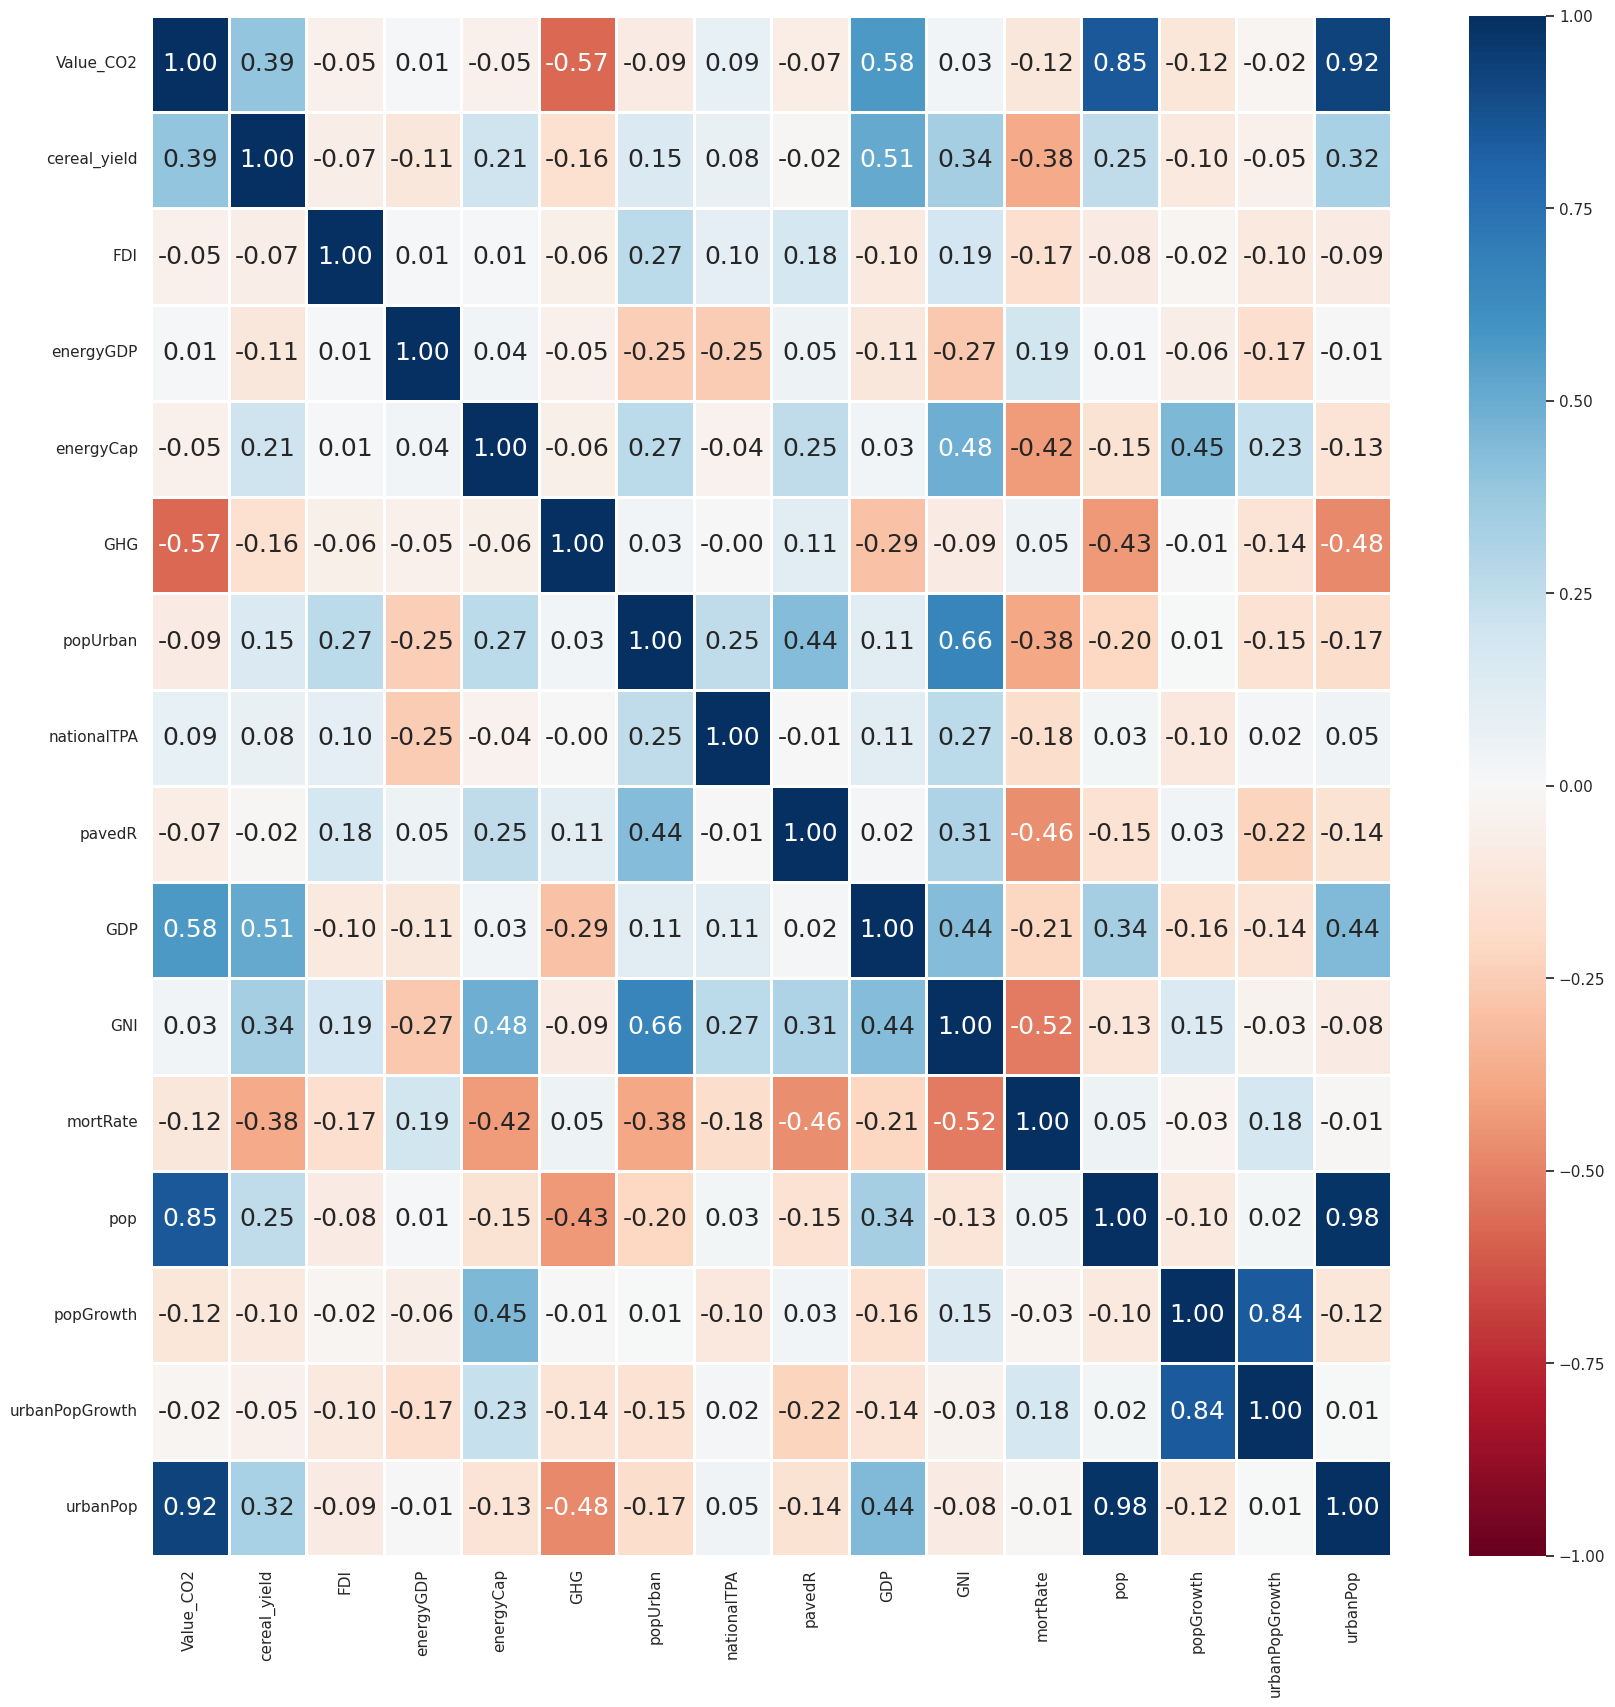

In [ ]:
#create new data frame to combine all variable's value to do correlation
#start with CO2 values
all_values = df_CO2_final[["Value_CO2"]].copy()

#use loop over all other variables and append their values
for var_name, df_var in co2_vs_variable.items():
    #make sure the order matches by Country_Year
    all_values[f"{var_name}"] = df_var[f"Value_{var_name}"].values

#drop rows with any missing values
all_values = all_values.dropna()

all_values.corr()

# Heatmap of the Correlation Matrix
f, axes = plt.subplots(1, 1, figsize=(20, 20))
sb.heatmap(all_values.corr(), vmin = -1, vmax = 1, linewidths = 1,
           annot = True, fmt = ".2f", annot_kws = {"size": 18}, cmap = "RdBu")



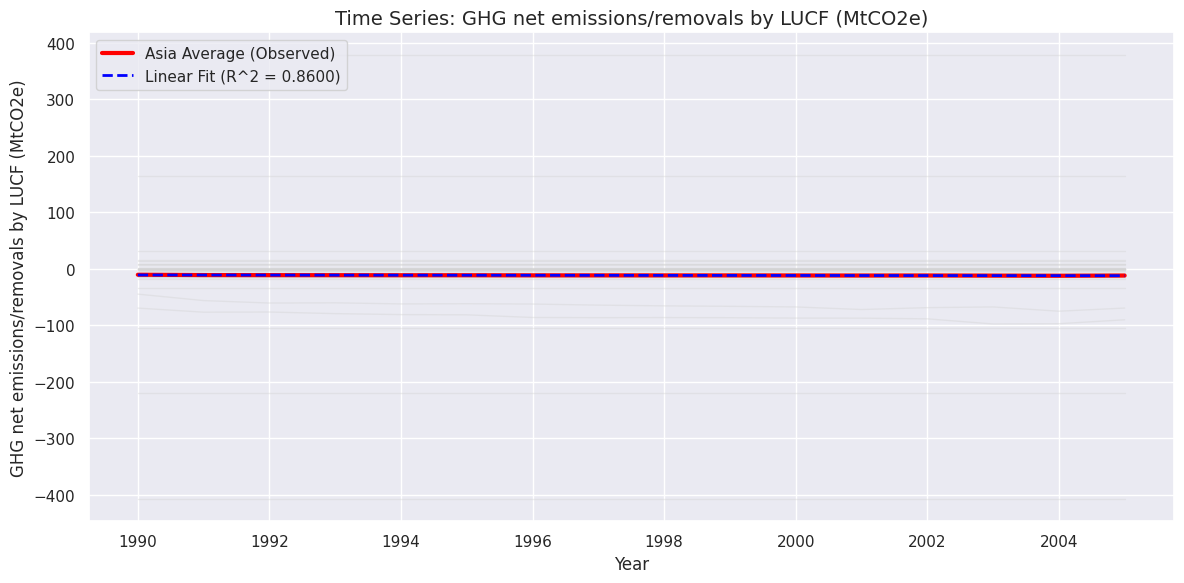

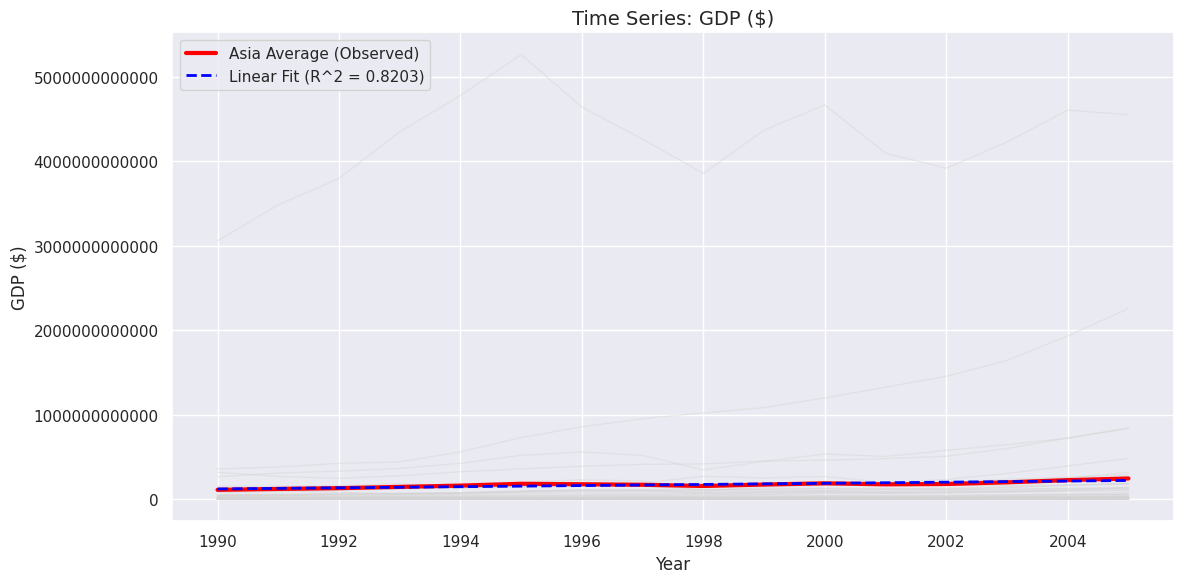

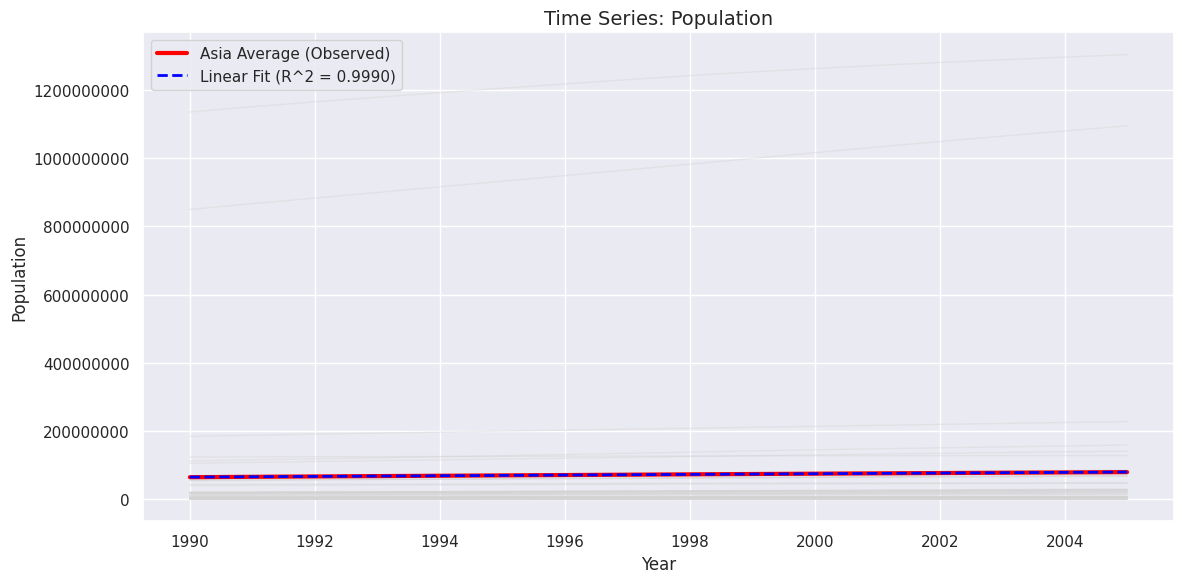

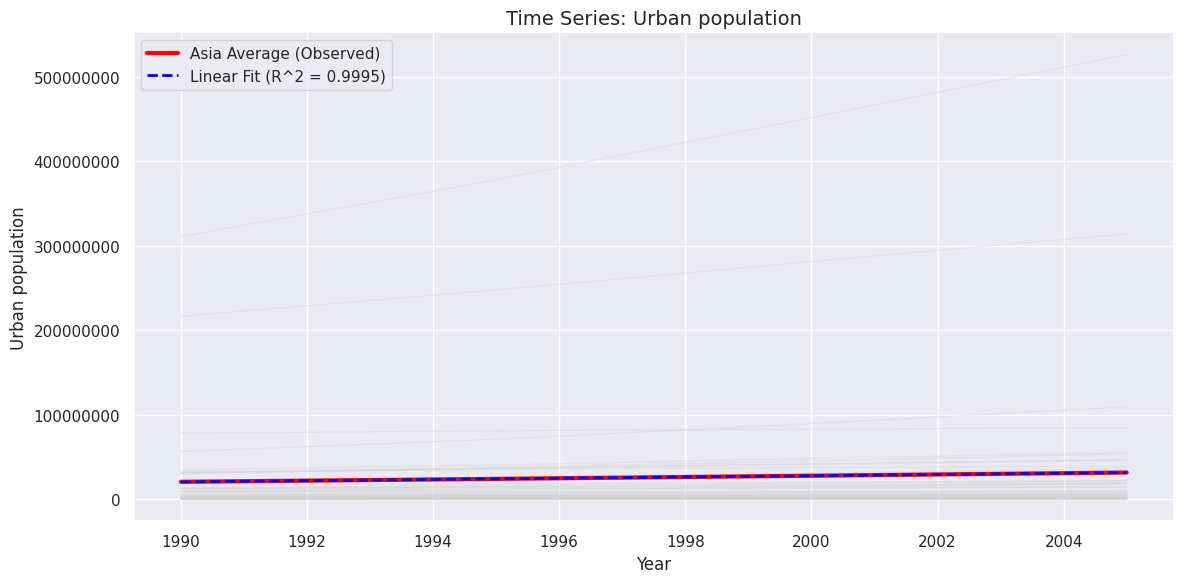

[{'Series Name': 'GHG net emissions/removals by LUCF (MtCO2e)', 'R^2': 0.859961273566994, 'Variable Name': 'GHG'}, {'Series Name': 'GDP ($)', 'R^2': 0.8203414161235252, 'Variable Name': 'GDP'}, {'Series Name': 'Population', 'R^2': 0.9989695160835821, 'Variable Name': 'pop'}, {'Series Name': 'Urban population', 'R^2': 0.999506712154079, 'Variable Name': 'urbanPop'}]


In [ ]:
def calculate_r2_and_plot(df_series, var_name, all_year_cols):
    #Calculates the R^2 value for a linear trend over time using Asia Average data, and generates a plot showing the trend line. It extracts the series name
    #directly from the DataFrame (avoiding 'series_map').

    #Returns a dictionary with Series Name and R^2.

    #extract the full series name directly from the DataFrame (no series_map needed)
    series_name = df_series["Series name"].iloc[0] if not df_series.empty else "Unknown Series"

    #melt the DataFrame to long format
    df_long = pd.melt(
        df_series,
        id_vars=["Country name", "Series name"],
        value_vars=[col for col in all_year_cols if col in df_series.columns],
        var_name="Year",
        value_name="Value"
    )
    df_long['Year'] = pd.to_numeric(df_long['Year'])

    #calculate the average per year
    df_avg = df_long.groupby('Year', as_index=False)['Value'].mean()
    df_avg = df_avg.dropna()


    #perform Linear Regression
    X = df_avg[['Year']]
    Y = df_avg['Value']

    linreg = LinearRegression()
    linreg.fit(X, Y)
    Y_pred = linreg.predict(X)

    #calculate R-squared value
    r_squared = r2_score(Y, Y_pred)

    #plotting Preparation (for visualization if desired)
    df_avg['Country name'] = 'Asia Average'
    df_avg['Series name'] = series_name
    df_plot_data = pd.concat([df_long, df_avg], ignore_index=True)

    df_asia_avg = df_plot_data[df_plot_data['Country name'] == 'Asia Average']
    df_countries = df_plot_data[df_plot_data['Country name'] != 'Asia Average']

    #plotting
    plt.figure(figsize=(12, 6))

    #plot individual countries (light gray for context)
    for country in df_countries['Country name'].unique():
        country_data = df_countries[df_countries['Country name'] == country]
        plt.plot(
            country_data['Year'],
            country_data['Value'],
            color='lightgray',
            alpha=0.4,
            linewidth=1,
            zorder=1
        )

    #plot the Asia Average (Observed data)
    plt.plot(
        df_asia_avg['Year'],
        df_asia_avg['Value'],
        color='red',
        linewidth=3,
        label='Asia Average (Observed)',
        zorder=2
    )

    #plot the Linear Regression Line (Predicted data)
    plt.plot(
        df_asia_avg['Year'],
        Y_pred,
        color='blue',
        linestyle='--',
        linewidth=2,
        label=f'Linear Fit (R^2 = {r_squared:.4f})',
        zorder=3
    )

    #customize the plot
    plt.title(f'Time Series: {series_name}', fontsize=14)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel(series_name, fontsize=12)
    plt.ticklabel_format(style='plain', axis='y')
    plt.xticks(df_plot_data['Year'].unique().astype(int)[::2])
    plt.legend(loc='upper left')
    plt.show()
    plt.close()

    return {'Series Name': series_name, 'R^2': r_squared, 'Variable Name': var_name}

#iteration over the dataDict
r2_results = []

year_cols_str = [1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,
                 2003,2004,2005]

#the for loop structure to iterate over the dictionary:

newer_data = dataDict

selected_vars = ["GHG", "GDP", "urbanPop", "pop"]

for var_name, df_series in newer_data.items():
    if var_name in selected_vars:
        r2_data = calculate_r2_and_plot(df_series, var_name, year_cols_str)
        r2_results.append(r2_data)

print(r2_results)

In [ ]:
"""
#SAME ARIMA BUT THIS HARDCODED (1,1,1), which for some scenario wouldnt suit best
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

def add_arima_forecast_to_dataDict(dataDict, selected_vars, train_years, test_years, forecast_horizon=10):
    updated_dict = {}

    for var_name, df_series in dataDict.items():
        if var_name not in selected_vars:
            continue

        print(f"\n Processing {var_name}...")

        #identify year columns
        year_cols = [c for c in df_series.columns if str(c).isdigit()]
        year_cols = sorted(map(int, year_cols))

        #compute Asia average for each year
        asia_avg = df_series[year_cols].mean(axis=0)
        asia_avg = asia_avg.reset_index()
        asia_avg.columns = ["Year", "Value"]

        #split train/test
        train = asia_avg[asia_avg["Year"].isin(train_years)]
        test = asia_avg[asia_avg["Year"].isin(test_years)]

        if train.empty or test.empty:
            print(f"Skipping {var_name} (not enough data for train/test).")
            continue

        #fit ARIMA model
        y_train = train["Value"].values
        model = ARIMA(y_train, order=(1, 1, 1))
        model_fit = model.fit()

        #forecast test years
        n_test = len(test)
        y_pred_test = model_fit.forecast(steps=n_test)
        mse = mean_squared_error(test["Value"].values, y_pred_test)
        print(f"{var_name} → Test MSE = {mse:.4f}")

        #forecast next 10 years after last available year
        total_steps = n_test + forecast_horizon
        forecast_values = model_fit.forecast(steps=total_steps)

        last_train_year = train["Year"].max()
        future_years = [last_train_year + i for i in range(1, total_steps + 1)]

        #add forecast columns into DataFrame
        for i, year in enumerate(future_years[-forecast_horizon:]):  #only add the 10 years
            df_series[year] = forecast_values[n_test + i]  #asia average forecast for all countries

        updated_dict[var_name] = df_series

        #plot every graphs
        plt.figure(figsize=(10, 5))
        plt.plot(train["Year"], train["Value"], marker="o", label="Train Data")
        plt.plot(test["Year"], test["Value"], marker="o", color="green", label="Test Data (Actual)")
        plt.plot(test["Year"], y_pred_test, "--", color="orange", label="Test Forecast")
        plt.plot(future_years[-forecast_horizon:], forecast_values[-forecast_horizon:], "--", color="blue", label=f"Future Forecast (+{forecast_horizon} yrs)")
        plt.title(f"ARIMA Forecast for {var_name}\nTest MSE = {mse:.4f}")
        plt.xlabel("Year")
        plt.ylabel(var_name)
        plt.legend()
        plt.show()

    return updated_dict


#example usage
selected_vars = ["urbanPop", "pop", "GDP", "cereal_yield"]

train_years = list(range(1990, 2006))  #train: 1990–2005
test_years = [2006, 2007, 2008]        #test: 2006–2008

#add forecasts (next s10 years)
dataDict = add_arima_forecast_to_dataDict(dataDict, selected_vars, train_years, test_years, forecast_horizon=10)

#check updated columns
for var in selected_vars:
    print(f"\n{var} columns:", [c for c in dataDict[var].columns if str(c).isdigit()][-15:])
"""

'\n#SAME ARIMA BUT THIS HARDCODED (1,1,1), which for some scenario wouldnt suit best\nimport pandas as pd\nimport matplotlib.pyplot as plt\nfrom statsmodels.tsa.arima.model import ARIMA\nfrom sklearn.metrics import mean_squared_error\n\ndef add_arima_forecast_to_dataDict(dataDict, selected_vars, train_years, test_years, forecast_horizon=10):\n    updated_dict = {}\n\n    for var_name, df_series in dataDict.items():\n        if var_name not in selected_vars:\n            continue\n\n        print(f"\n Processing {var_name}...")\n\n        #identify year columns\n        year_cols = [c for c in df_series.columns if str(c).isdigit()]\n        year_cols = sorted(map(int, year_cols))\n\n        #compute Asia average for each year\n        asia_avg = df_series[year_cols].mean(axis=0)\n        asia_avg = asia_avg.reset_index()\n        asia_avg.columns = ["Year", "Value"]\n\n        #split train/test\n        train = asia_avg[asia_avg["Year"].isin(train_years)]\n        test = asia_avg[asia_a

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/p

best ARIMA order for GHG: (6, 3, 4) with MSE = 0.0082


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


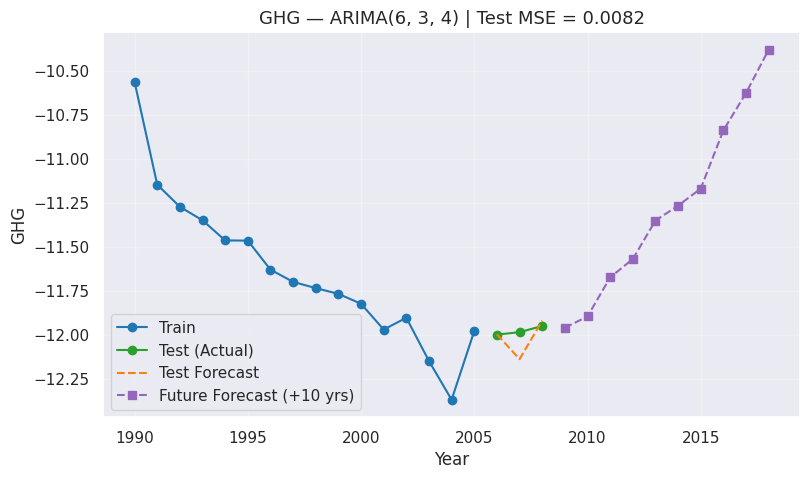

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/p

best ARIMA order for GDP: (6, 3, 5) with MSE = 3494852486381821952.0000


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


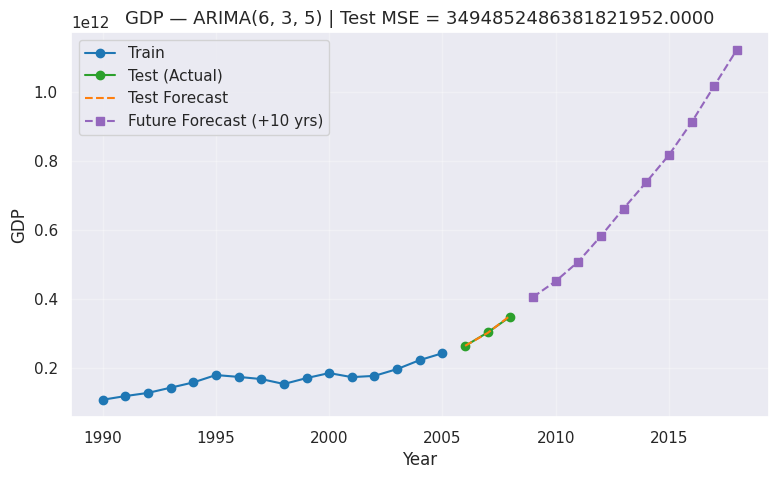

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too

best ARIMA order for pop: (4, 2, 4) with MSE = 21099736.8399


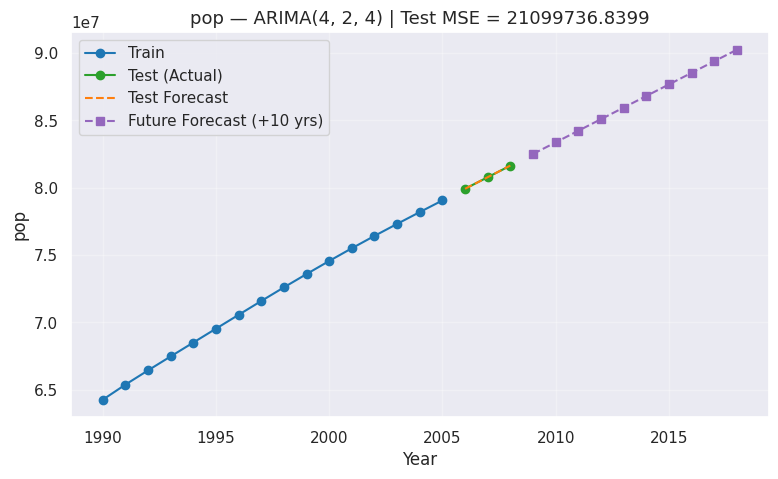

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend.

best ARIMA order for urbanPop: (4, 3, 4) with MSE = 1851293128.8859


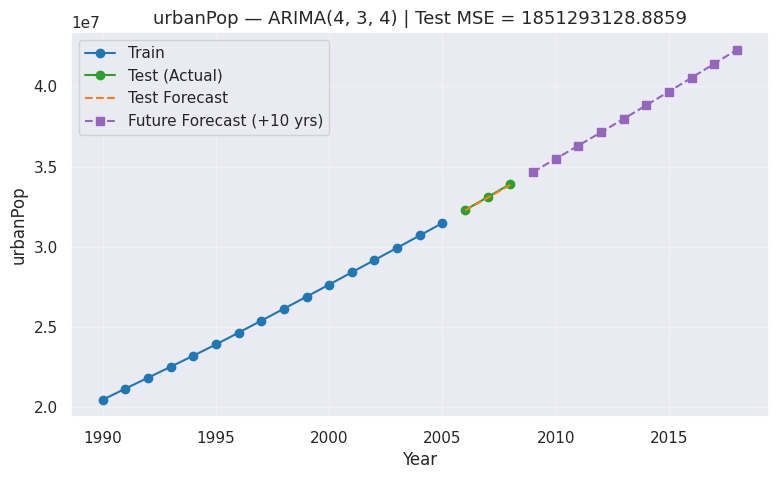

In [ ]:
#better arima model than the above, since this one find the best combination to find the lowerst MSE
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
import itertools

def add_arima_forecast_to_dataDict(dataDict, selected_vars, train_years, test_years, forecast_horizon=10):
    updated_dict = {}

    #search range for ARIMA(p,d,q)
    p_values = [4, 5, 6, 7]
    d_values = [1, 2, 3]
    q_values = [4, 5, 6, 7]

    for var_name, df_series in dataDict.items():
        if var_name not in selected_vars:
            continue

        #identify year columns, sort and conv to int
        year_cols = [c for c in df_series.columns if str(c).isdigit()]
        year_cols = sorted(map(int, year_cols))

        # compute Asia average for each year
        asia_avg = df_series[year_cols].mean(axis=0).reset_index()
        asia_avg.columns = ["Year", "Value"]

        # split train/test
        train = asia_avg[asia_avg["Year"].isin(train_years)]
        test = asia_avg[asia_avg["Year"].isin(test_years)]

        if train.empty or test.empty:
            continue

        y_train = train["Value"].values

        #find best (p,d,q) by finding lowest MSE on test data
        best_order, best_mse = None, float("inf")

        #iterate using itertools
        for p, d, q in itertools.product(p_values, d_values, q_values):
            try:
                model = ARIMA(y_train, order=(p, d, q))
                model_fit = model.fit()
                y_pred_test = model_fit.forecast(steps=len(test))
                mse = mean_squared_error(test["Value"].values, y_pred_test)
                if mse < best_mse:
                    best_mse = mse
                    best_order = (p, d, q)
            except Exception:
                continue

        print(f"best ARIMA order for {var_name}: {best_order} with MSE = {best_mse:.4f}")

        #final order aft iteration
        final_model = ARIMA(y_train, order=best_order)
        final_fit = final_model.fit()

        #predict
        total_steps = len(test) + forecast_horizon
        forecast_values = final_fit.forecast(steps=total_steps)
        last_train_year = train["Year"].max()
        future_years = [last_train_year + i for i in range(1, total_steps + 1)]

        #create copy
        df_out = df_series.copy(deep=True)

        #add forecast by slicing last 10 years to dict
        for i, year in enumerate(future_years[-forecast_horizon:]):
            df_out[year] = forecast_values[len(test) + i]

        updated_dict[var_name] = df_out

        #plot
        plt.figure(figsize=(9,5))
        plt.plot(train["Year"], train["Value"], "o-", label="Train", color="#1f77b4")
        plt.plot(test["Year"], test["Value"], "o-", label="Test (Actual)", color="#2ca02c")
        plt.plot(test["Year"], forecast_values[:len(test)], "--", label="Test Forecast", color="#ff7f0e")
        plt.plot(future_years[-forecast_horizon:], forecast_values[-forecast_horizon:], "--s",
                 label=f"Future Forecast (+{forecast_horizon} yrs)", color="#9467bd")
        plt.title(f"{var_name} — ARIMA{best_order} | Test MSE = {best_mse:.4f}", fontsize=13)
        plt.xlabel("Year")
        plt.ylabel(var_name)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

    return updated_dict

newDataDict = {}

selected_vars = ["urbanPop", "pop", "GHG", "GDP"]

train_years = list(range(1990, 2006))  #train: 1990–2005
test_years = [2006, 2007, 2008]        #test: 2006–2008

newdataDict = add_arima_forecast_to_dataDict(dataDict, selected_vars, train_years, test_years, forecast_horizon=10)



In [ ]:
newdataDict

{'GHG':               Country name                                  Series name  \
 3497           Afghanistan  GHG net emissions/removals by LUCF (MtCO2e)   
 3500  United Arab Emirates  GHG net emissions/removals by LUCF (MtCO2e)   
 3502               Armenia  GHG net emissions/removals by LUCF (MtCO2e)   
 3507            Azerbaijan  GHG net emissions/removals by LUCF (MtCO2e)   
 3512            Bangladesh  GHG net emissions/removals by LUCF (MtCO2e)   
 3514               Bahrain  GHG net emissions/removals by LUCF (MtCO2e)   
 3523     Brunei Darussalam  GHG net emissions/removals by LUCF (MtCO2e)   
 3524                Bhutan  GHG net emissions/removals by LUCF (MtCO2e)   
 3531                 China  GHG net emissions/removals by LUCF (MtCO2e)   
 3543                Cyprus  GHG net emissions/removals by LUCF (MtCO2e)   
 3567               Georgia  GHG net emissions/removals by LUCF (MtCO2e)   
 3581  Hong Kong SAR, China  GHG net emissions/removals by LUCF (MtCO2e)   
 3586

MAKE THE CO2 x DATASET TABLE

In [ ]:
Var1 = co2_vs_variable['GDP']
Var2 = co2_vs_variable['pop']
Var3 = co2_vs_variable['GHG']
Var4 = co2_vs_variable['urbanPop']

In [ ]:
def SEPARATOR(A):
  # Ensure Year is numeric
  A["Year"] = pd.to_numeric(A["Year"], errors="coerce")

  # Split
  df_1990_2004 = A[(A["Year"] >= 1990) & (A["Year"] <= 2004)].copy()
  df_2005_plus = A[A["Year"] >= 2005].copy()

  return df_1990_2004, df_2005_plus

Var1_1, Var1_2 = SEPARATOR(Var1)
Var2_1, Var2_2 = SEPARATOR(Var2)
Var3_1, Var3_2 = SEPARATOR(Var3)
Var4_1, Var4_2 = SEPARATOR(Var4)

Intercept 	: b =  [104701.082311]
Coefficients 	: a =  [[4.31608164e-07]]


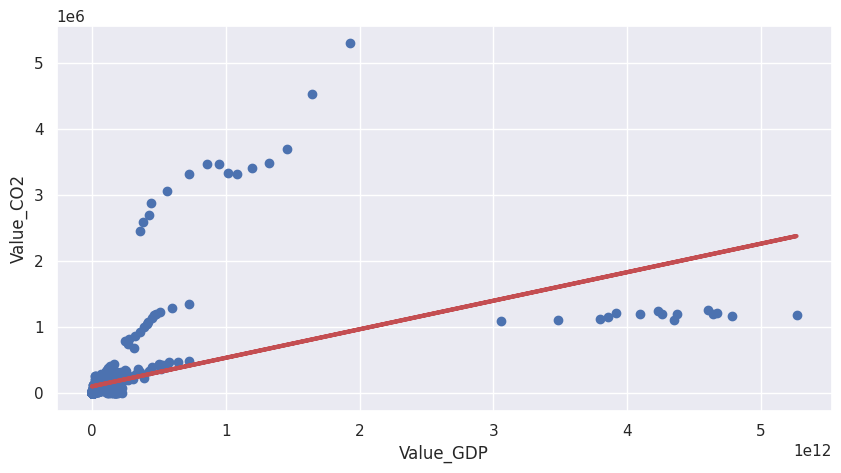

Explained Variance (R^2) 	: 0.2550362546903828
Mean Squared Error (MSE) 	: 206901541995.21396



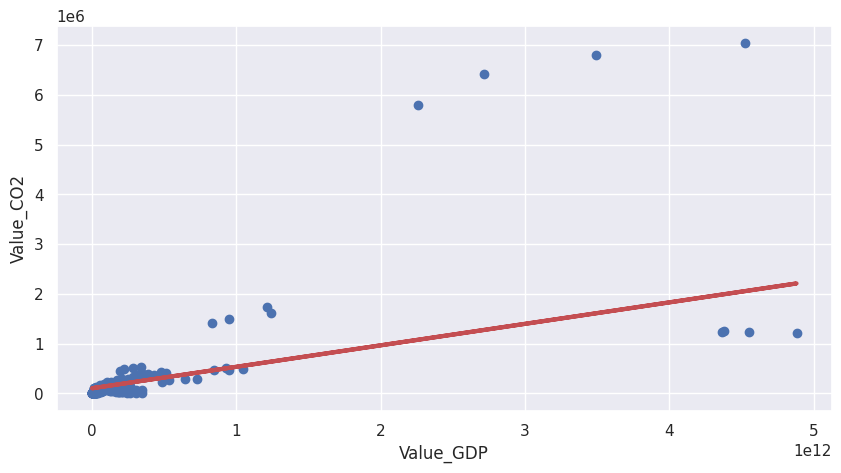

Explained Variance (R^2) 	: 0.3799986777869917
Mean Squared Error (MSE) 	: 556695748300.0537

Intercept 	: b =  [24898.06396535]
Coefficients 	: a =  [[0.00211196]]


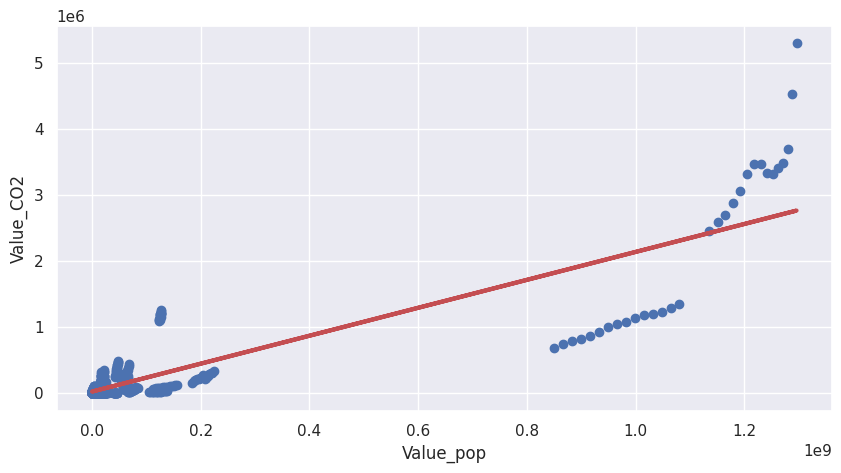

Explained Variance (R^2) 	: 0.7575667981833792
Mean Squared Error (MSE) 	: 67331871654.83957



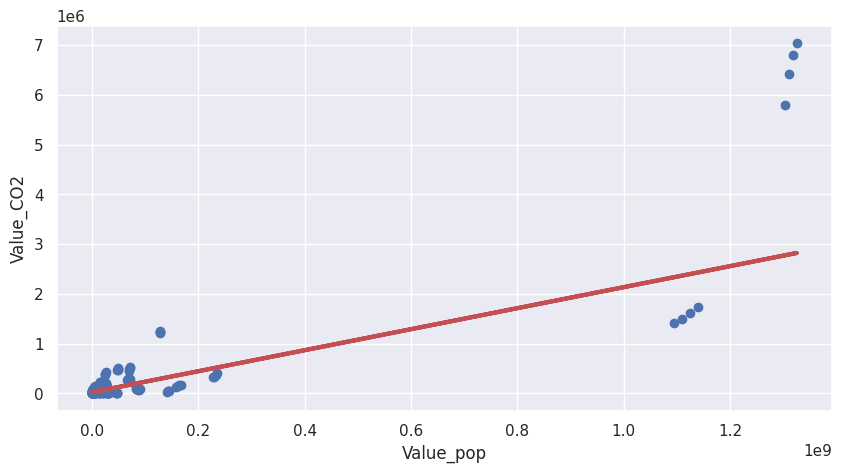

Explained Variance (R^2) 	: 0.6334574678294209
Mean Squared Error (MSE) 	: 329116506561.88837

Intercept 	: b =  [136379.86800145]
Coefficients 	: a =  [[-3394.78644366]]


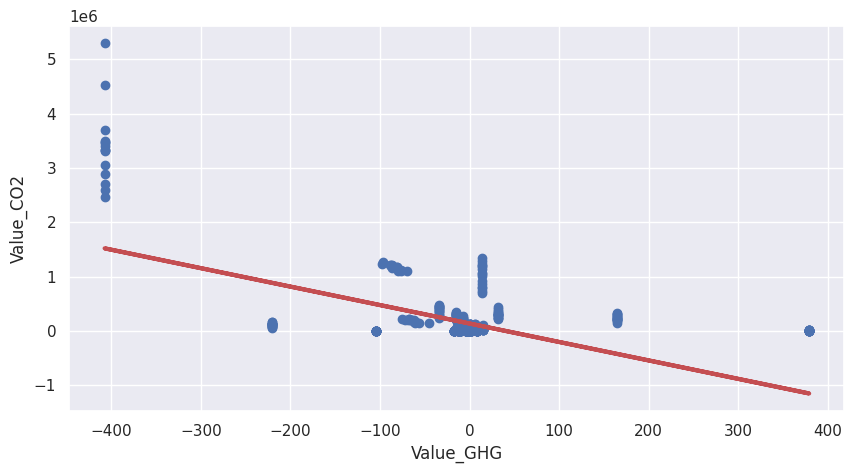

Explained Variance (R^2) 	: 0.3445613138450758
Mean Squared Error (MSE) 	: 182037415515.31342



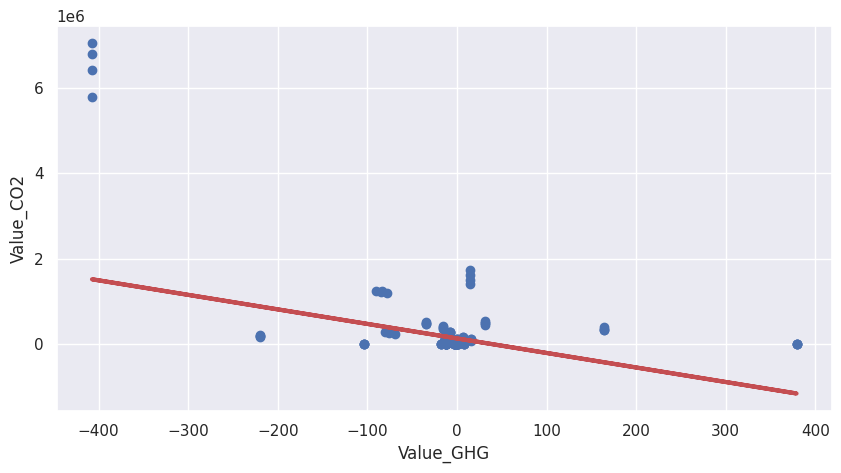

Explained Variance (R^2) 	: 0.2819936540029975
Mean Squared Error (MSE) 	: 644693915558.5598

Intercept 	: b =  [-5665.34697958]
Coefficients 	: a =  [[0.00712396]]


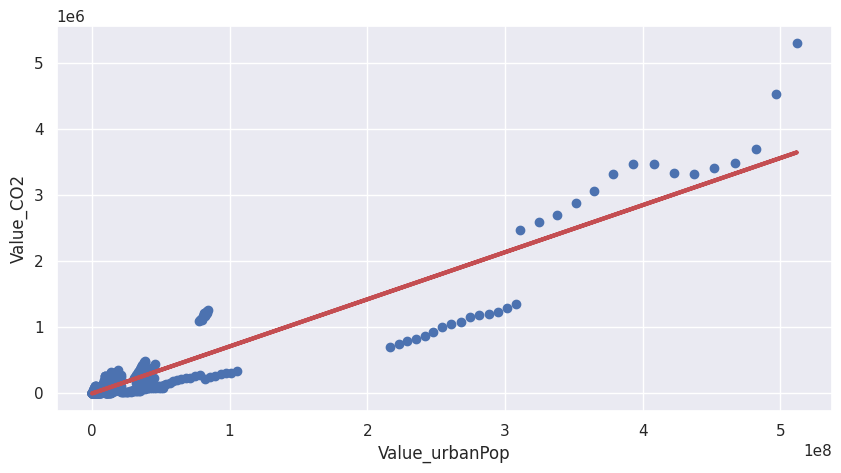

Explained Variance (R^2) 	: 0.867665494742135
Mean Squared Error (MSE) 	: 36753752607.98288



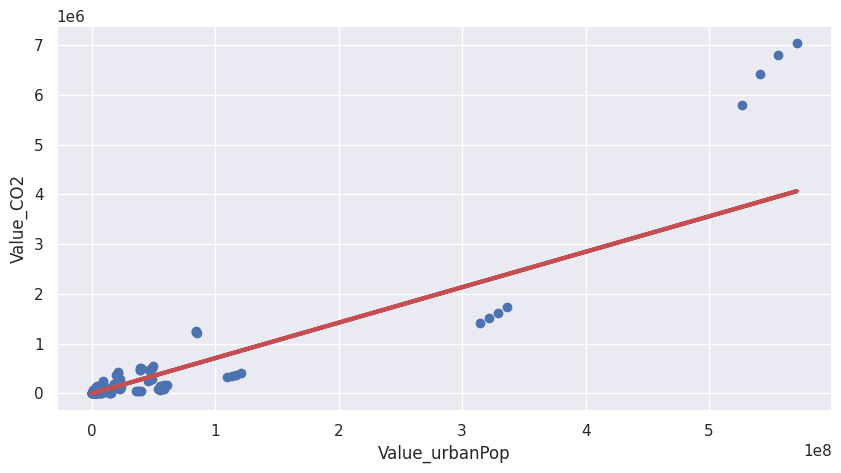

Explained Variance (R^2) 	: 0.8065999064656706
Mean Squared Error (MSE) 	: 173652871266.6267



In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
linreg = LinearRegression()

def LINREG(VARIABLE_1, VARIABLE_2, COLUMN_1, COLUMN_2):
  X_train = pd.DataFrame(VARIABLE_1[COLUMN_1])
  Y_train = pd.DataFrame(VARIABLE_1[COLUMN_2])
  X_test = pd.DataFrame(VARIABLE_2[COLUMN_1])
  Y_test = pd.DataFrame(VARIABLE_2[COLUMN_2])

  #TRAIN DATA
  linreg.fit(X_train, Y_train)
  print('Intercept \t: b = ', linreg.intercept_)
  print('Coefficients \t: a = ', linreg.coef_)

  train_pred = linreg.predict(X_train)

  f = plt.figure(figsize=(10, 5))
  plt.scatter(X_train, Y_train)
  plt.plot(X_train, train_pred, color = "r", linewidth = 3)
  plt.xlabel(COLUMN_1)
  plt.ylabel(COLUMN_2)
  plt.show()

  print("Explained Variance (R^2) \t:", r2_score(Y_train, train_pred))
  print("Mean Squared Error (MSE) \t:", mean_squared_error(Y_train, train_pred))
  print()

  #TEST DATA
  test_pred = linreg.predict(X_test)

  f = plt.figure(figsize=(10, 5))
  plt.scatter(X_test, Y_test)
  plt.plot(X_test, test_pred, color = "r", linewidth = 3)
  plt.xlabel(COLUMN_1)
  plt.ylabel(COLUMN_2)
  plt.show()

  print("Explained Variance (R^2) \t:", r2_score(Y_test, test_pred))
  print("Mean Squared Error (MSE) \t:", mean_squared_error(Y_test, test_pred))
  print()

LINREG(Var1_1, Var1_2, 'Value_GDP', 'Value_CO2')
LINREG(Var2_1, Var2_2, 'Value_pop', 'Value_CO2')
LINREG(Var3_1, Var3_2, 'Value_GHG', 'Value_CO2')
LINREG(Var4_1, Var4_2, 'Value_urbanPop', 'Value_CO2')

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

#combine top 5 variables with CO2
#create new df without screwing base df
all_var = df_CO2_final.copy()

#combine each variable's data with co2
for var in ["urbanPop", "pop", "GDP", "GHG"]:
    df_var = co2_vs_variable[var][["Country name", "Year", f"Value_{var}"]]
    all_var = pd.merge(all_var, df_var, on=["Country name", "Year"], how="inner")

all_var

,Country name,Year,Value_CO2,Value_urbanPop,Value_pop,Value_GDP,Value_GHG
0,Afghanistan,1990,2676.910,3.481333e+06,19023678.0,2.461666e+09,-10.561619
1,United Arab Emirates,1990,52009.061,1.430636e+06,1808642.0,3.365323e+10,-9.665000
2,Armenia,1990,3681.668,2.392669e+06,3544695.0,2.256839e+09,-10.561619
3,Azerbaijan,1990,44172.682,3.844383e+06,7159000.0,8.858006e+09,-1.075000
4,Bangladesh,1990,15533.412,2.084069e+07,105256026.0,3.012878e+10,7.838000
...,...,...,...,...,...,...,...
926,Timor-Leste,2008,190.684,2.947715e+05,1079749.0,4.979189e+08,-11.950706
927,Turkey,2008,283979.814,4.871042e+07,70923730.0,7.303375e+11,-80.579712
928,Uzbekistan,2008,124905.354,1.005690e+07,27313700.0,2.791752e+10,0.417500
929,Vietnam,2008,127384.246,2.369805e+07,85122300.0,9.027376e+10,15.104700


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score


#split train and test dataset, 2005 onwards as test data
train_data = all_var[all_var["Year"] < 2006]
test_data  = all_var[all_var["Year"].between(2006, 2008)]

X_train = train_data[["Value_urbanPop", "Value_pop", "Value_GDP", "Value_GHG"]]
y_train = train_data["Value_CO2"]
X_test = test_data[["Value_urbanPop", "Value_pop", "Value_GDP", "Value_GHG"]]
y_test = test_data["Value_CO2"]

#linreg
linreg = LinearRegression()
linreg.fit(X_train, y_train)


LinearRegression()

In [ ]:
"""
#same code, but basically here split random

#split train and test dataset randomly with 25% as test data
X = all_var[["Value_urbanPop", "Value_pop", "Value_GDP", "Value_cereal_yield"]]
y = all_var["Value_CO2"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)

#linreg
linreg = LinearRegression()
linreg.fit(X_train, y_train)
"""

'\n#same code, but basically here split random\n\n#split train and test dataset randomly with 25% as test data\nX = all_var[["Value_urbanPop", "Value_pop", "Value_GDP", "Value_cereal_yield"]]\ny = all_var["Value_CO2"]\nX_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)\n\n#linreg\nlinreg = LinearRegression()\nlinreg.fit(X_train, y_train)\n'

<Axes: xlabel='Value_CO2'>

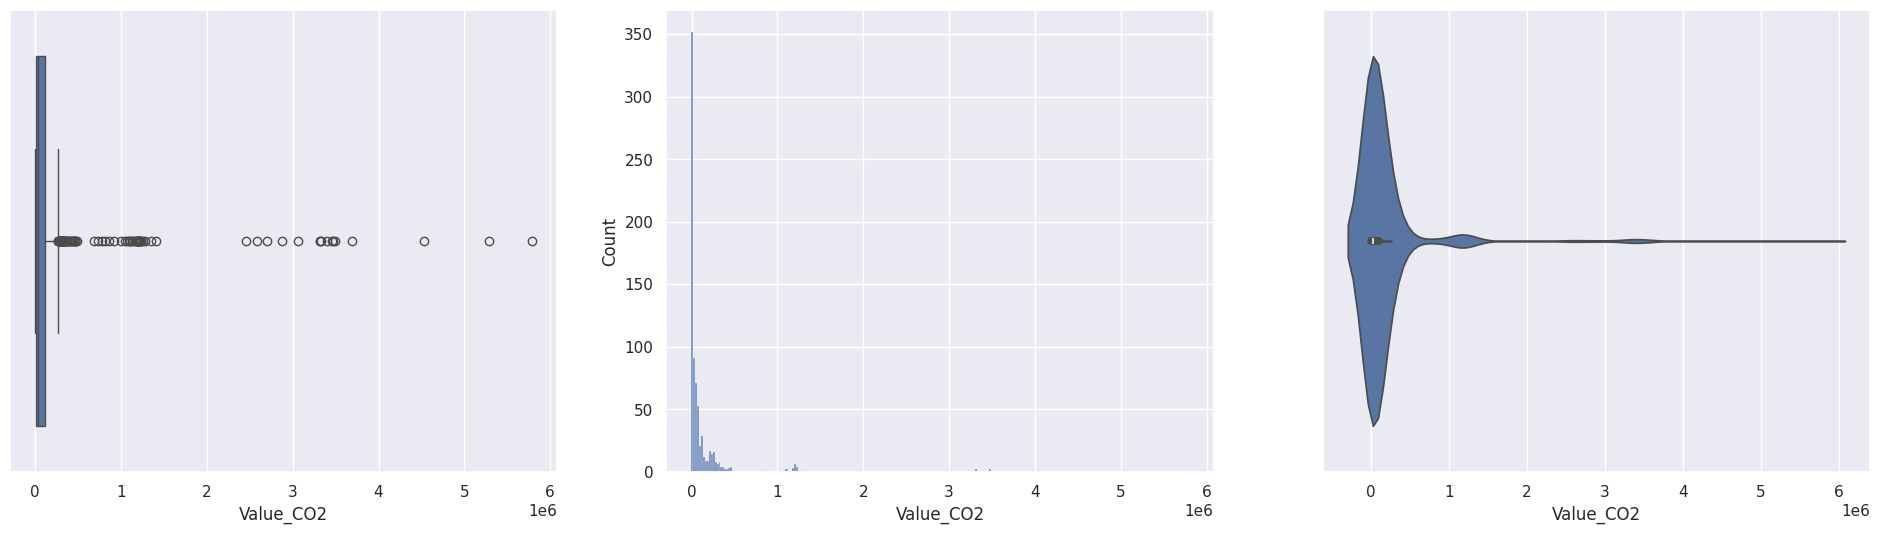

In [ ]:
#draw the distribution of response
f, axes = plt.subplots(1, 3, figsize=(24, 6))
sb.boxplot(data = y_train, orient = "h", ax = axes[0])
sb.histplot(data = y_train, ax = axes[1])
sb.violinplot(data = y_train, orient = "h", ax = axes[2])

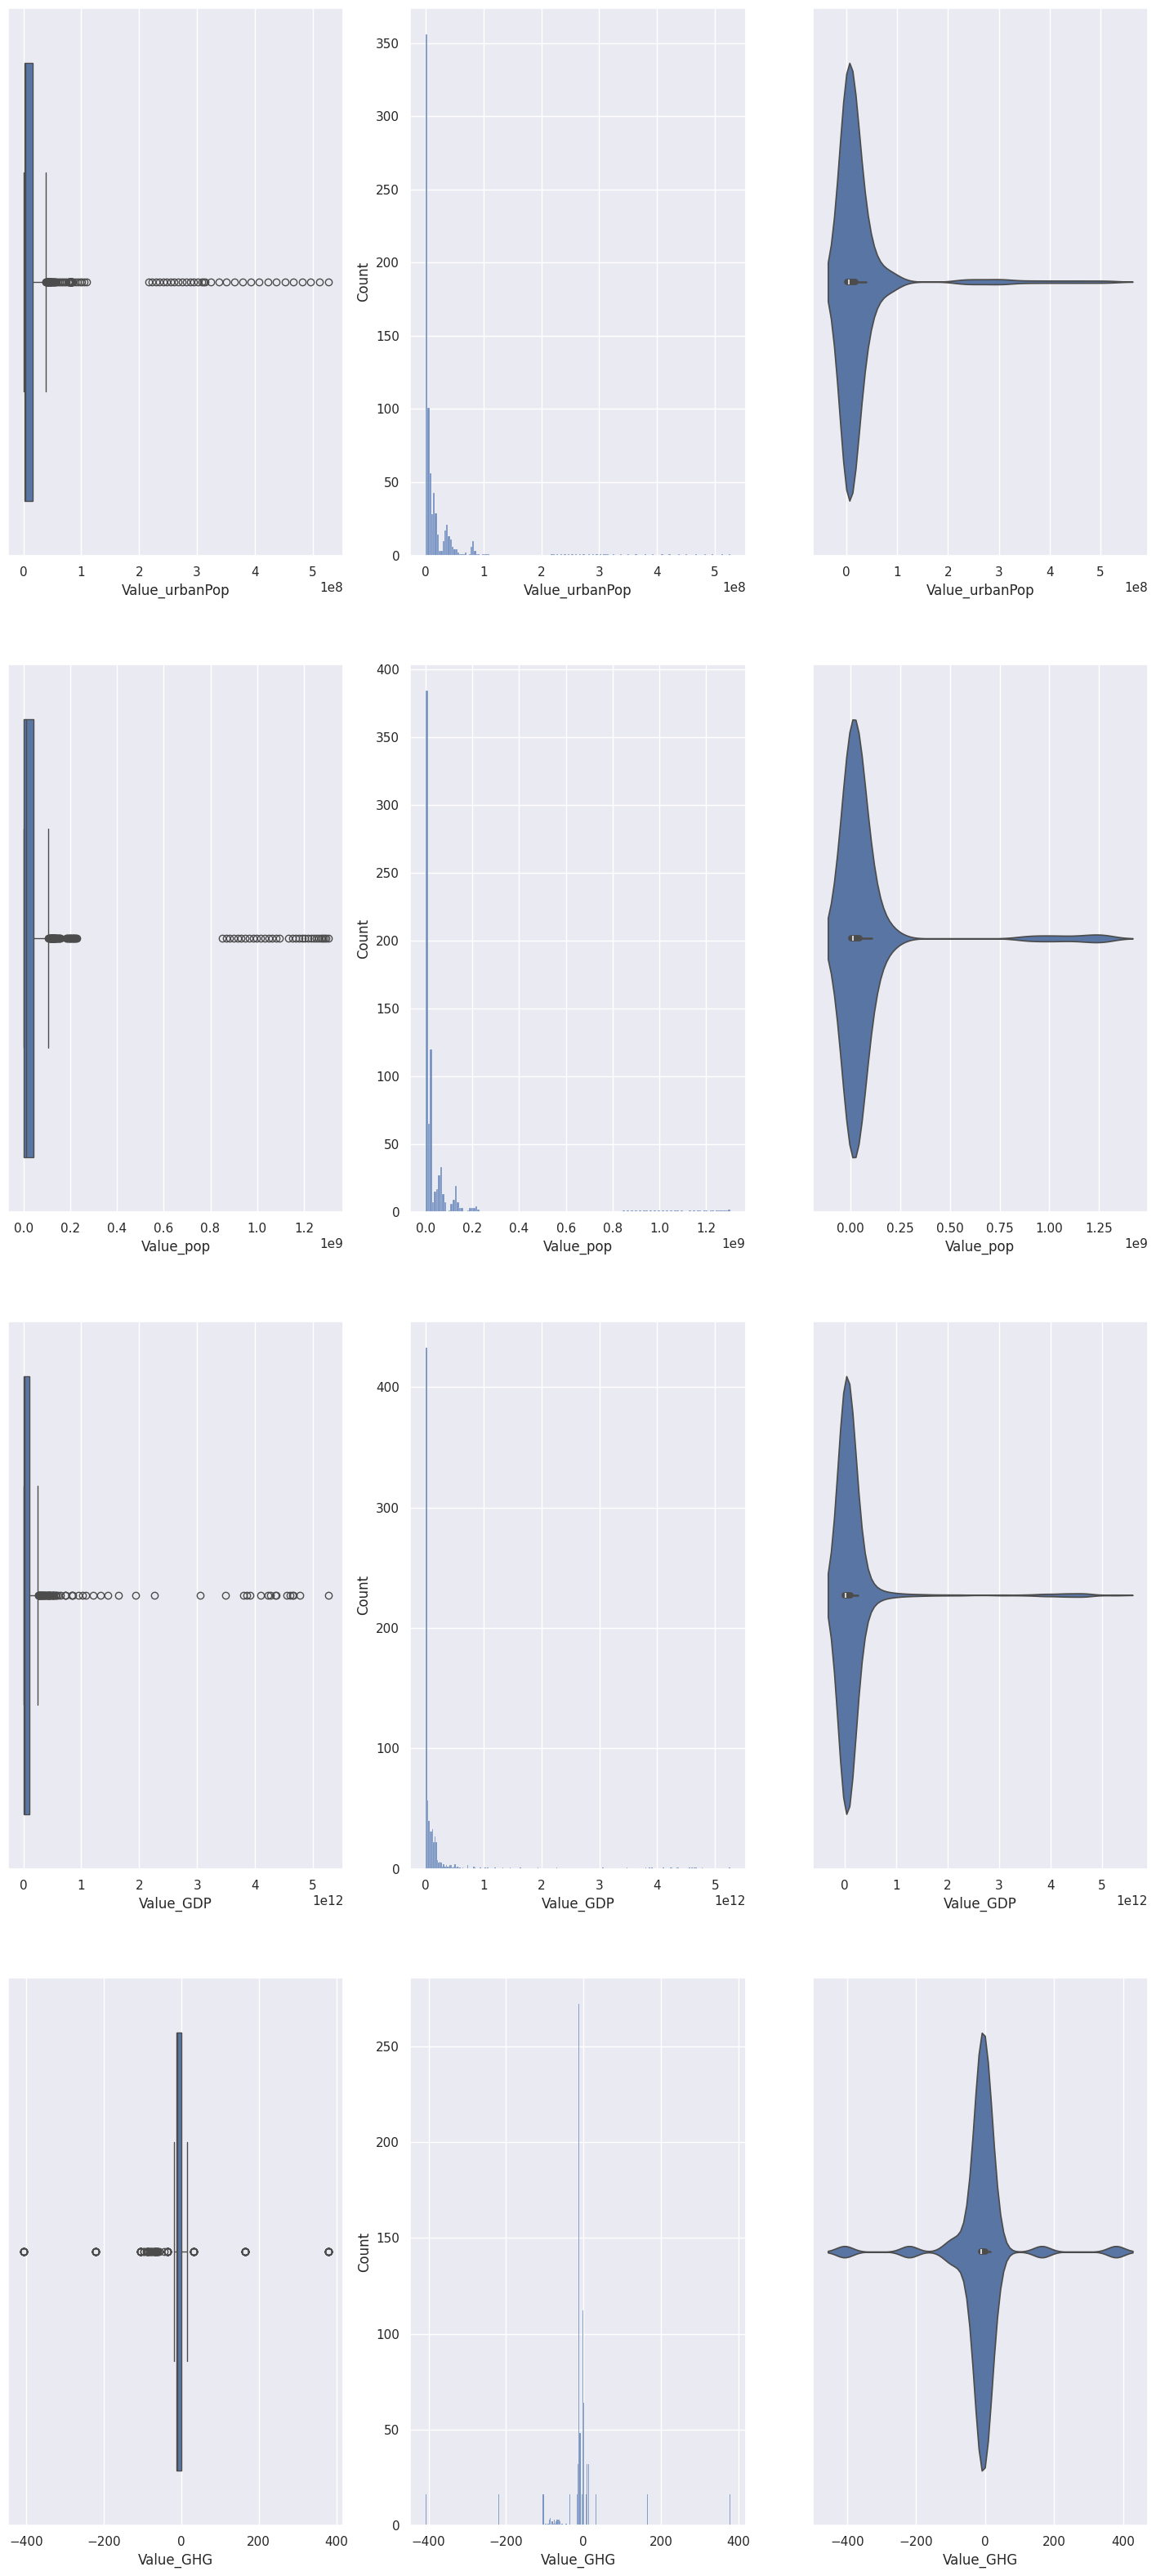

In [ ]:
#draw the distributions of all predictors
f, axes = plt.subplots(4, 3, figsize=(18, 40))

count = 0
for var in X_train:
    sb.boxplot(data = X_train[var], orient = "h", ax = axes[count,0])
    sb.histplot(data = X_train[var], ax = axes[count,1])
    sb.violinplot(data = X_train[var], orient = "h", ax = axes[count,2])
    count += 1
plt.savefig("my_plotaaa.png")

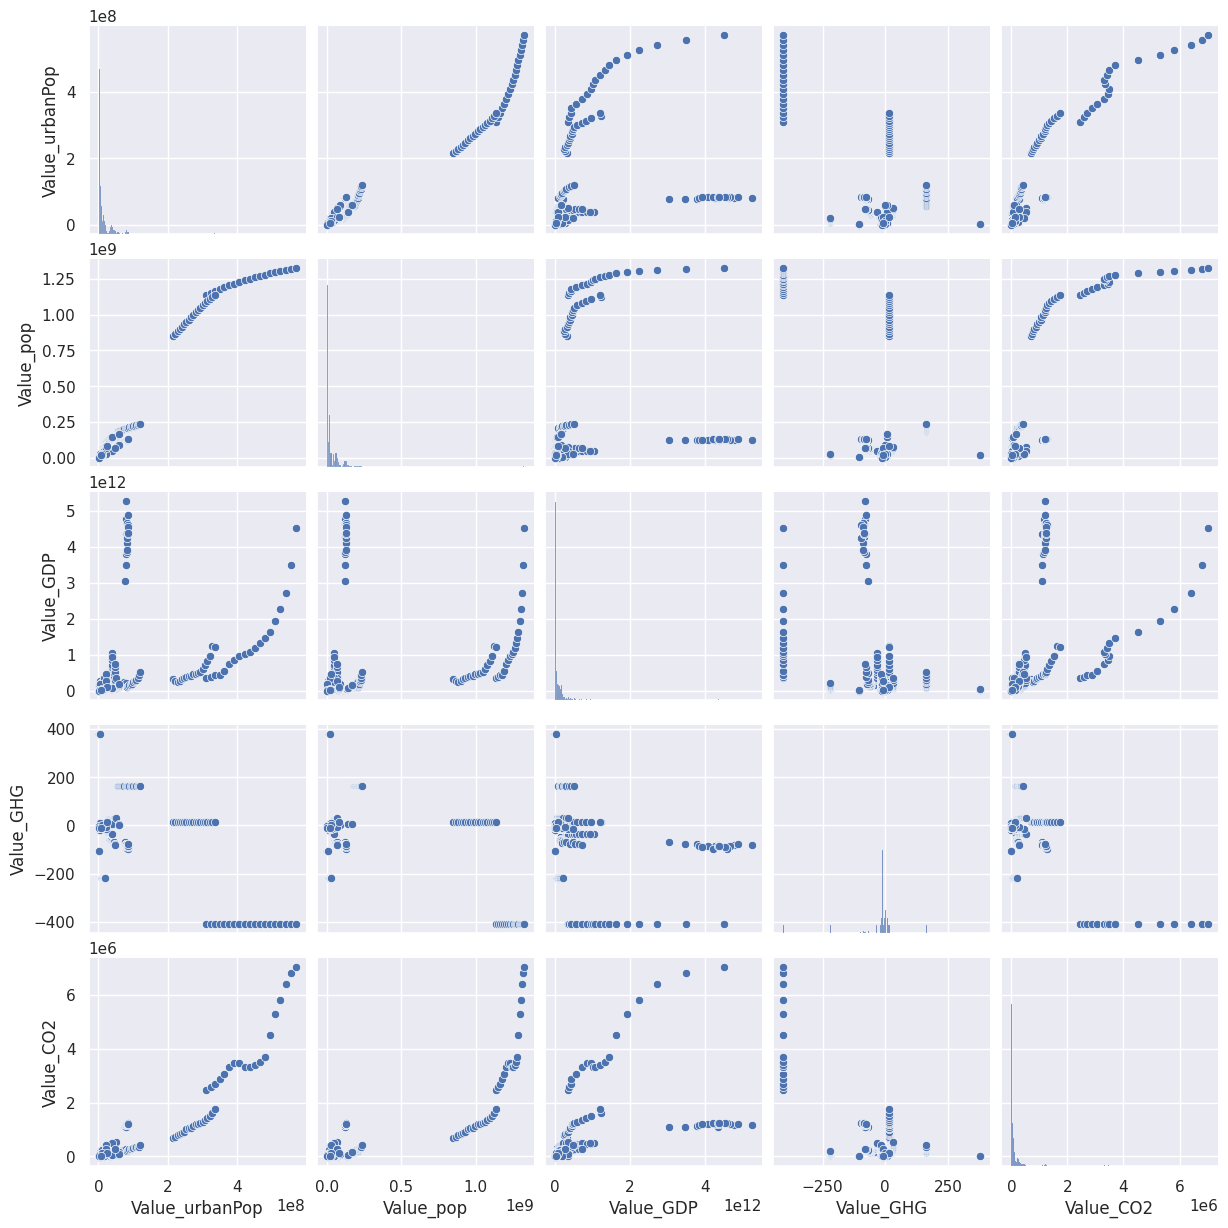

In [ ]:
sb.pairplot(data = all_var[["Value_urbanPop", "Value_pop", "Value_GDP", "Value_GHG","Value_CO2"]])

Intercept: -28851.203253888263

Coefficients:
        Predictors  Coefficients
0  Value_urbanPop  1.391632e-02
2       Value_GDP  7.728969e-08
1       Value_pop -2.399209e-03
3       Value_GHG -7.821994e+02 



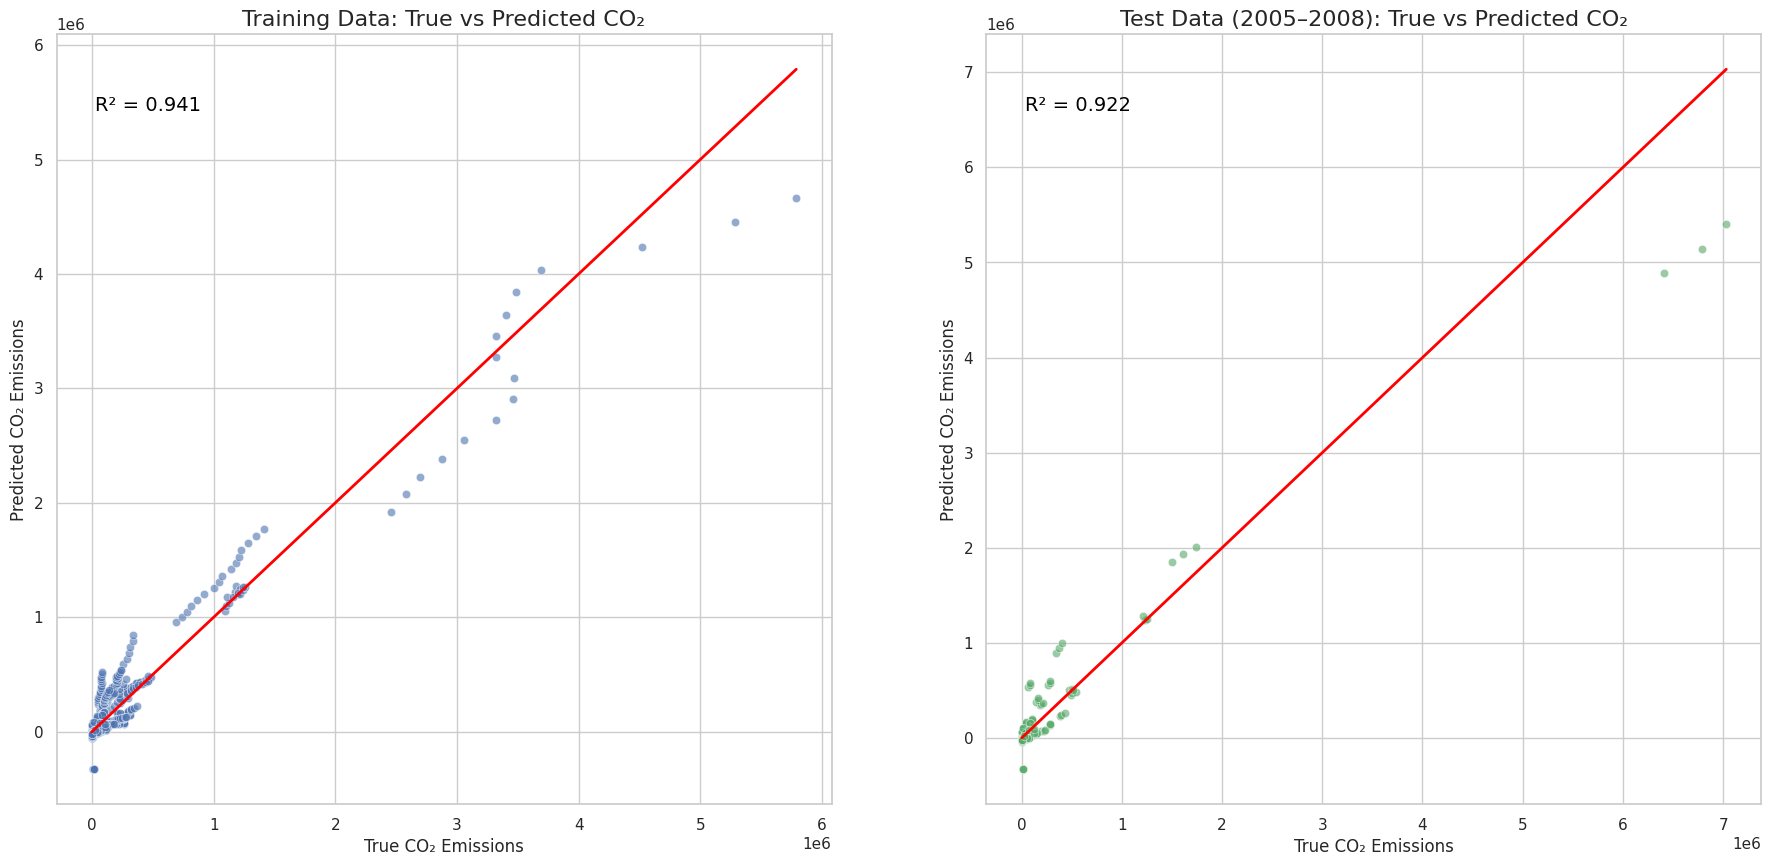

Goodness of Fit:
Train R²: 0.941
Train MSE: 17886669474.161

Test R²: 0.922
Test MSE: 74905238458.359


In [ ]:
  #print out the coeff
coef = pd.DataFrame({
    "Predictors": X_train.columns,
    "Coefficients": linreg.coef_
}).sort_values(by="Coefficients", ascending=False)

print("Intercept:", linreg.intercept_)
print("\nCoefficients:\n", coef, "\n")

# predict test data
y_train_pred = linreg.predict(X_train)
y_test_pred = linreg.predict(X_test)

#plot true value vs predicted value
sb.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(22, 10))

#train plot
sb.scatterplot(x=y_train, y=y_train_pred, color="#4C72B0", alpha=0.6, ax=axes[0])
sb.lineplot(x=y_train, y=y_train, color="red", linewidth=2, ax=axes[0])
axes[0].set_title("Training Data: True vs Predicted CO₂", fontsize=16)
axes[0].set_xlabel("True CO₂ Emissions")
axes[0].set_ylabel("Predicted CO₂ Emissions")
axes[0].text(0.05, 0.9, f"R² = {r2_score(y_train, y_train_pred):.3f}",
             transform=axes[0].transAxes, fontsize=14, color="black")

#test plot
sb.scatterplot(x=y_test, y=y_test_pred, color="#55A868", alpha=0.6, ax=axes[1])
sb.lineplot(x=y_test, y=y_test, color="red", linewidth=2, ax=axes[1])
axes[1].set_title("Test Data (2005–2008): True vs Predicted CO₂", fontsize=16)
axes[1].set_xlabel("True CO₂ Emissions")
axes[1].set_ylabel("Predicted CO₂ Emissions")
axes[1].text(0.05, 0.9, f"R² = {r2_score(y_test, y_test_pred):.3f}",
             transform=axes[1].transAxes, fontsize=14, color="black")

plt.show()

#calculate r squared and MSE
print("Goodness of Fit:")
print(f"Train R²: {r2_score(y_train, y_train_pred):.3f}")
print(f"Train MSE: {mean_squared_error(y_train, y_train_pred):.3f}")
print()
print(f"Test R²: {r2_score(y_test, y_test_pred):.3f}")
print(f"Test MSE: {mean_squared_error(y_test, y_test_pred):.3f}")

In [ ]:
# Gradient Boosting Regressor

Feature Importances:

       Predictors  Importance
1       Value_pop    0.537959
3       Value_GHG    0.242031
0  Value_urbanPop    0.119037
2       Value_GDP    0.100973 



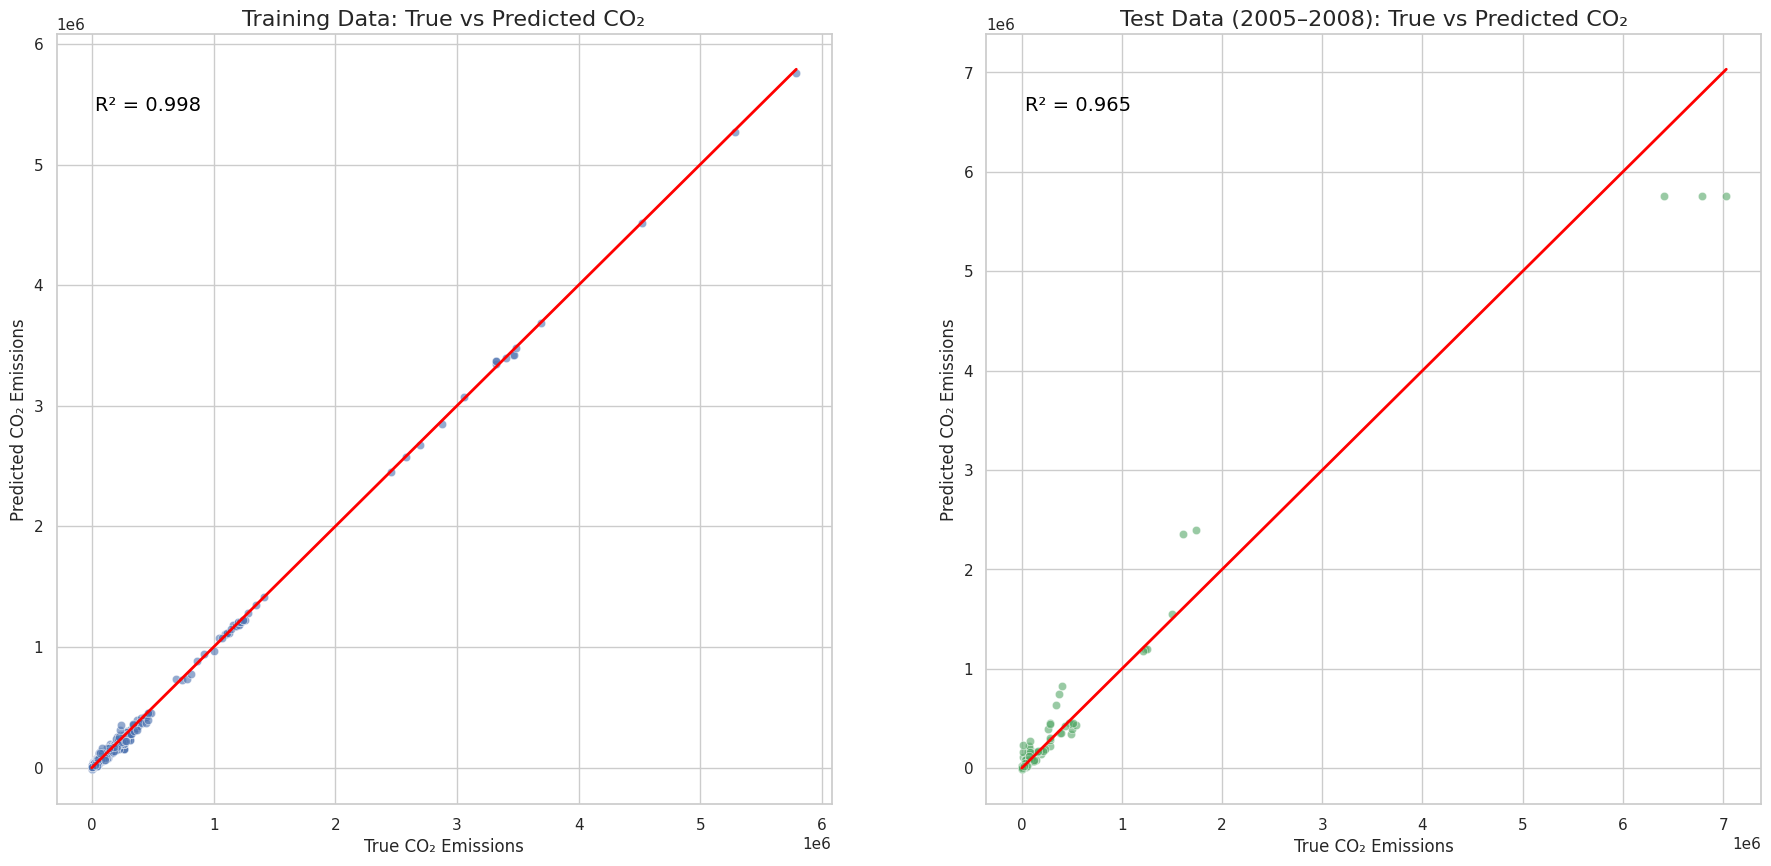

Goodness of Fit:
Train R²: 0.998
Train MSE: 471506427.224

Test R²: 0.965
Test MSE: 33181428898.537


In [ ]:
#fit grad boost
gbr = GradientBoostingRegressor()
gbr.fit(X_train, y_train)

#importance
importance_df = pd.DataFrame({
    "Predictors": X_train.columns,
    "Importance": gbr.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("Feature Importances:\n")
print(importance_df, "\n")

#predict
y_train_pred = gbr.predict(X_train)
y_test_pred = gbr.predict(X_test)

#set plot
sb.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(22, 10))

#train
sb.scatterplot(x=y_train, y=y_train_pred, color="#4C72B0", alpha=0.6, ax=axes[0])
sb.lineplot(x=y_train, y=y_train, color="red", linewidth=2, ax=axes[0])
axes[0].set_title("Training Data: True vs Predicted CO₂", fontsize=16)
axes[0].set_xlabel("True CO₂ Emissions")
axes[0].set_ylabel("Predicted CO₂ Emissions")
axes[0].text(0.05, 0.9, f"R² = {r2_score(y_train, y_train_pred):.3f}",
             transform=axes[0].transAxes, fontsize=14, color="black")

#test
sb.scatterplot(x=y_test, y=y_test_pred, color="#55A868", alpha=0.6, ax=axes[1])
sb.lineplot(x=y_test, y=y_test, color="red", linewidth=2, ax=axes[1])
axes[1].set_title("Test Data (2005–2008): True vs Predicted CO₂", fontsize=16)
axes[1].set_xlabel("True CO₂ Emissions")
axes[1].set_ylabel("Predicted CO₂ Emissions")
axes[1].text(0.05, 0.9, f"R² = {r2_score(y_test, y_test_pred):.3f}",
             transform=axes[1].transAxes, fontsize=14, color="black")

plt.show()

#R2 MSE
print("Goodness of Fit:")
print(f"Train R²: {r2_score(y_train, y_train_pred):.3f}")
print(f"Train MSE: {mean_squared_error(y_train, y_train_pred):.3f}")
print()
print(f"Test R²: {r2_score(y_test, y_test_pred):.3f}")
print(f"Test MSE: {mean_squared_error(y_test, y_test_pred):.3f}")


In [ ]:
#DO FOR PREDICTION

In [ ]:
#same as before, create new dictionary of co2 vs all other variables, but this dictionary is only for predict

co2_vs_variable_predict = {}

df_CO2_final = df_CO2.melt(
    id_vars=["Country name", "Series name"],
    var_name="Year",
    value_name="Value_CO2"
)
df_CO2_final["Year"] = df_CO2_final["Year"].astype(int)
df_CO2_final = df_CO2_final[["Country name", "Year", "Value_CO2"]]

for var_name, df_var in newdataDict.items():
    if var_name == "CO2":
        continue

    df_var_long = df_var.melt(
        id_vars=["Country name", "Series name"],
        var_name="Year",
        value_name=f"Value_{var_name}"
    )
    df_var_long["Year"] = df_var_long["Year"].astype(int)
    df_var_final = df_var_long[["Country name", "Year", f"Value_{var_name}"]]

    df_combined = pd.merge(df_var_final, df_CO2_final, on=["Country name", "Year"], how="left")

    co2_vs_variable_predict[var_name] = df_combined

co2_vs_variable_predict["urbanPop"]


,Country name,Year,Value_urbanPop,Value_CO2
0,Afghanistan,1990,3.481333e+06,2676.910
1,United Arab Emirates,1990,1.430636e+06,52009.061
2,Armenia,1990,2.392669e+06,3681.668
3,Azerbaijan,1990,3.844383e+06,44172.682
4,Bangladesh,1990,2.084069e+07,15533.412
...,...,...,...,...
1416,Timor-Leste,2018,4.228200e+07,NaN
1417,Turkey,2018,4.228200e+07,NaN
1418,Uzbekistan,2018,4.228200e+07,NaN
1419,Vietnam,2018,4.228200e+07,NaN


In [ ]:
#create dataframe combined all from the dictionary

#start with a base var, here i choose urbanPop
base_var = "urbanPop"
all_var_predict = co2_vs_variable_predict[base_var][["Country name", "Year", f"Value_{base_var}", "Value_CO2"]].copy()


#merge the other 3 variables
for var in ["GDP", "GHG", "pop"]:
    a = co2_vs_variable_predict[var][["Country name", "Year", f"Value_{var}", "Value_CO2"]]
    all_var_predict = pd.merge(all_var_predict, a, on=["Country name", "Year", "Value_CO2"], how="left")

all_var_predict

,Country name,Year,Value_urbanPop,Value_CO2,Value_GDP,Value_GHG,Value_pop
0,Afghanistan,1990,3.481333e+06,2676.910,2.461666e+09,-10.561619,1.902368e+07
1,United Arab Emirates,1990,1.430636e+06,52009.061,3.365323e+10,-9.665000,1.808642e+06
2,Armenia,1990,2.392669e+06,3681.668,2.256839e+09,-10.561619,3.544695e+06
3,Azerbaijan,1990,3.844383e+06,44172.682,8.858006e+09,-1.075000,7.159000e+06
4,Bangladesh,1990,2.084069e+07,15533.412,3.012878e+10,7.838000,1.052560e+08
...,...,...,...,...,...,...,...
1416,Timor-Leste,2018,4.228200e+07,NaN,1.122467e+12,-10.378503,9.025160e+07
1417,Turkey,2018,4.228200e+07,NaN,1.122467e+12,-10.378503,9.025160e+07
1418,Uzbekistan,2018,4.228200e+07,NaN,1.122467e+12,-10.378503,9.025160e+07
1419,Vietnam,2018,4.228200e+07,NaN,1.122467e+12,-10.378503,9.025160e+07


In [ ]:
#take predict data from 2008 onwards
predict_data = all_var_predict[all_var_predict["Year"] > 2008]

X_predict = predict_data[["Value_urbanPop", "Value_pop", "Value_GDP", "Value_GHG"]]

#here, since we use the same model made previously
linreg = LinearRegression()
linreg.fit(X_train, y_train)

LinearRegression()

In [ ]:
predict_data

,Country name,Year,Value_urbanPop,Value_CO2,Value_GDP,Value_GHG,Value_pop
931,Afghanistan,2009,3.466821e+07,NaN,4.062165e+11,-11.960754,8.251181e+07
932,United Arab Emirates,2009,3.466821e+07,NaN,4.062165e+11,-11.960754,8.251181e+07
933,Armenia,2009,3.466821e+07,NaN,4.062165e+11,-11.960754,8.251181e+07
934,Azerbaijan,2009,3.466821e+07,NaN,4.062165e+11,-11.960754,8.251181e+07
935,Bangladesh,2009,3.466821e+07,NaN,4.062165e+11,-11.960754,8.251181e+07
...,...,...,...,...,...,...,...
1416,Timor-Leste,2018,4.228200e+07,NaN,1.122467e+12,-10.378503,9.025160e+07
1417,Turkey,2018,4.228200e+07,NaN,1.122467e+12,-10.378503,9.025160e+07
1418,Uzbekistan,2018,4.228200e+07,NaN,1.122467e+12,-10.378503,9.025160e+07
1419,Vietnam,2018,4.228200e+07,NaN,1.122467e+12,-10.378503,9.025160e+07


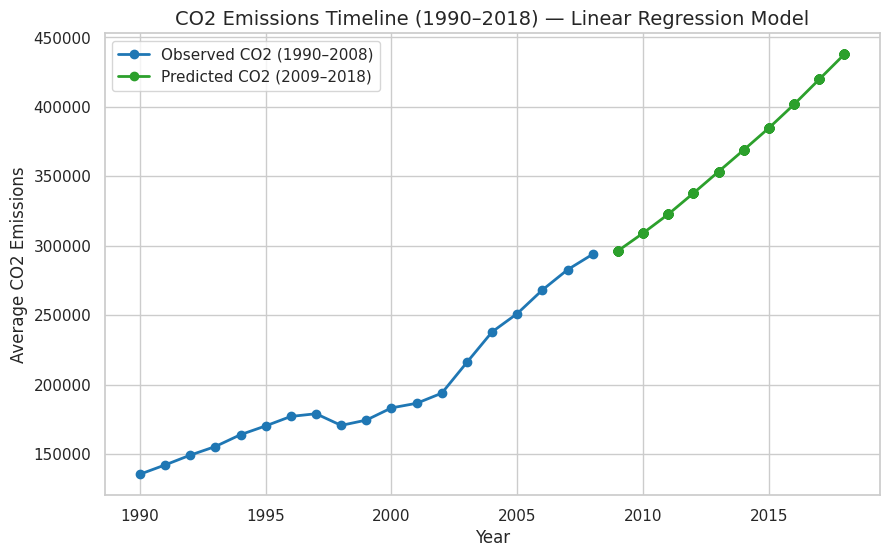

In [ ]:
#LINREG
X_predict = predict_data[["Value_urbanPop", "Value_pop", "Value_GDP", "Value_GHG"]]
y_predict_future = linreg.predict(X_predict)

#past data 1990 - 2008
actual = df_CO2_final.groupby("Year")["Value_CO2"].mean().reset_index()
actual = actual[actual["Year"] <= 2008]

predicted = pd.DataFrame({
    "Year": predict_data["Year"],
    "CO2": y_predict_future
})

#combine both from 1990–2018
timeline = pd.concat([actual.rename(columns={"Value_CO2": "CO2"}), predicted]).sort_values("Year")

#plot
plt.figure(figsize=(10,6))

#past
plt.plot(actual["Year"], actual["Value_CO2"], color="#1f77b4", marker="o", linewidth=2, label="Observed CO2 (1990–2008)")

#prediction
plt.plot(predicted["Year"], predicted["CO2"], color="#2ca02c", marker="o", linewidth=2, label="Predicted CO2 (2009–2018)")

plt.title("CO2 Emissions Timeline (1990–2018) — Linear Regression Model", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Average CO2 Emissions")
plt.legend()
plt.show()


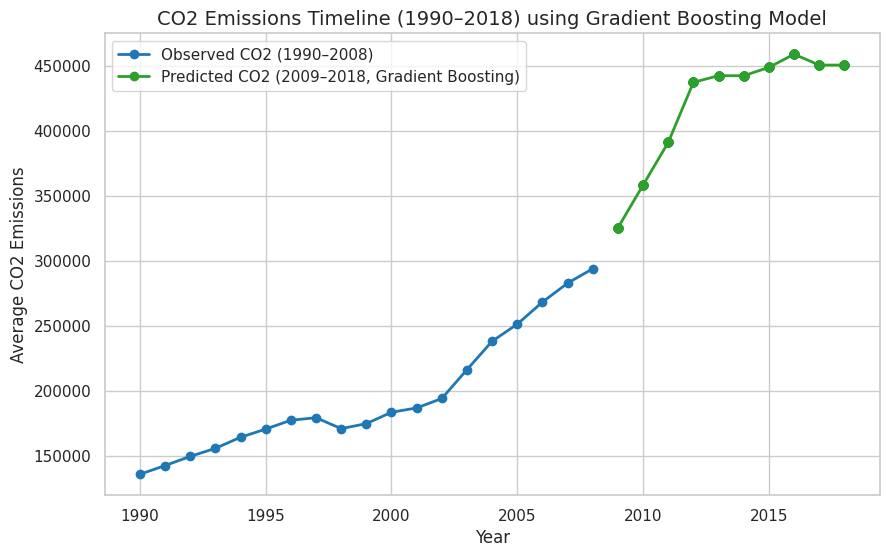

In [ ]:
#GRAD BOOSTING

X_train_grad = X_train.copy()
y_train_grad = y_train.copy()
X_test_grad = X_test.copy()
y_test_grad = y_test.copy()

gbr = GradientBoostingRegressor()
gbr.fit(X_train_grad, y_train_grad)

y_predict_future = gbr.predict(X_predict)

predicted = pd.DataFrame({"Year": predict_data["Year"],"CO2": y_predict_future})

plt.figure(figsize=(10,6))

#plot past
plt.plot(actual["Year"], actual["Value_CO2"], color="#1f77b4", marker="o", linewidth=2, label="Observed CO2 (1990–2008)")

#plot predicted (Gradient Boosting)
plt.plot(predict_data["Year"], y_predict_future, color="#2ca02c", marker="o", linewidth=2, label="Predicted CO2 (2009–2018, Gradient Boosting)")

plt.title("CO2 Emissions Timeline (1990–2018) using Gradient Boosting Model", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Average CO2 Emissions")
plt.legend()
plt.show()


In [ ]:
"""
Problem Stattement : Predict the CO2 Change for the Next 5 years Using Linear Regression and 50 years using Dynamic Regression

Missing Value : Ken

Test Data =
    "Cereal yield (kg per hectare)",#1
    "Foreign direct investment, net inflows (% of GDP)",#1
    "Urban population",#1
    "Paved roads (% of total roads)",#1'
    "Energy use per capita (kilograms of oil equivalent)",#1
    "Energy use per units of GDP (kg oil eq./$1,000 of 2005 PPP $)",#1'
    "GHG net emissions/removals by LUCF (MtCO2e)",#1''
    "Population in urban agglomerations >1million (%)",#1'
    "Nationally terrestrial protected areas (% of total land area)",#1
    "GDP ($)",#1
    "GNI per capita (Atlas $)",#1
    "Under-five mortality rate (per 1,000)",#1
    "Population growth (annual %)", #1
    "Population", #1
    "Urban population growth (annual %)", #1
}
}

Predicted Data =
    "CO2 emissions per capita (metric tons)",#1
    "CO2 emissions, total (KtCO2)",#1
    "CO2 emissions per units of GDP (kg/$1,000 of 2005 PPP $)"#1

Linear Regression + PLOT for 5 best predeictor and 5 worst predictor (use data from 1990 - 2011)
- bivariate for every test data with respect to each predicted data : Brandon
- multivariate : Shotaro

Grad Boosting + Comparing Result : Ken + Nico
"""

'\nProblem Stattement : Predict the CO2 Change for the Next 5 years Using Linear Regression and 50 years using Dynamic Regression\n\nMissing Value : Ken\n\nTest Data =\n    "Cereal yield (kg per hectare)",#1\n    "Foreign direct investment, net inflows (% of GDP)",#1\n    "Urban population",#1\n    "Paved roads (% of total roads)",#1\'\n    "Energy use per capita (kilograms of oil equivalent)",#1\n    "Energy use per units of GDP (kg oil eq./$1,000 of 2005 PPP $)",#1\'\n    "GHG net emissions/removals by LUCF (MtCO2e)",#1\'\'\n    "Population in urban agglomerations >1million (%)",#1\'\n    "Nationally terrestrial protected areas (% of total land area)",#1\n    "GDP ($)",#1\n    "GNI per capita (Atlas $)",#1\n    "Under-five mortality rate (per 1,000)",#1\n    "Population growth (annual %)", #1\n    "Population", #1\n    "Urban population growth (annual %)", #1\n}\n}\n\nPredicted Data =\n    "CO2 emissions per capita (metric tons)",#1\n    "CO2 emissions, total (KtCO2)",#1\n    "CO2 em